<div style="background-color: #f8f9fa; border-left: 6px solid #1a5276; padding: 25px; border-radius: 8px; box-shadow: 0 4px 8px rgba(0,0,0,0.05); font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">
    <h1 style="color: #1a5276; margin-top: 0; font-size: 26px; border-bottom: 2px solid #d4e6f1; padding-bottom: 10px;">
         Projet IDS IIoT : Détection d'Attaques Man-In-The-Middle (MITM) par Machine Learning
    </h1>
    <p style="font-size: 15px; line-height: 1.6; color: #333;">
        <strong style="color: #1a5276;">Contexte :</strong> Ce notebook documente la création d'un Système de Détection d'Intrusions (IDS) basé sur l'IA pour sécuriser les réseaux de l'Internet des Objets Industriels (IIoT). Face aux vulnérabilités des protocoles industriels, nous utilisons des algorithmes d'apprentissage automatique pour analyser le trafic réseau et repérer les comportements anormaux.
    </p>
    <p style="font-size: 15px; line-height: 1.6; color: #333; margin-bottom: 0;">
        <strong style="color: #1a5276;">Objectif :</strong> Traiter des données brutes issues de journaux réseau (fichiers Zeek extraits de PCAP), extraire des caractéristiques comportementales pertinentes, et entraîner un modèle capable de distinguer le trafic légitime (Bénin) des attaques par usurpation (ARP Spoofing, IP Spoofing, Impersonation).
    </p>
</div>

# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import json
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix
from scipy import stats
import itertools

# Preparation du Jeu de Donnees

<div style="background-color: #f4f8fb; border-left: 6px solid #2980b9; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-bottom: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #34495e;">
        <strong style="color: #2980b9;">Approche Méthodologique :</strong><br>
        Comme l'illustre l'arborescence de notre répertoire de travail, les données réseau brutes ne sont pas centralisées dans un seul fichier. Elles sont réparties sur plusieurs fichiers CSV, chacun correspondant à une journée de capture spécifique et à des scénarios d'attaques isolés :
    </p>
    <ul style="font-size: 14px; color: #34495e; line-height: 1.7;">
        <li><strong style="color: #27ae60;">Trafic Nominal :</strong> Des fichiers capturent le comportement de base (Bénin) du réseau dans des conditions normales d'opération.</li>
        <li><strong style="color: #c0392b;">Scénarios Malveillants :</strong> Des fichiers spécifiques injectent des vecteurs d'attaques précis pour générer des anomalies contextuelles.</li>
    </ul>
    <p style="font-size: 14px; line-height: 1.6; color: #34495e; margin-bottom: 0;">
        <strong style="color: #2980b9;">Action réalisée dans cette section :</strong><br>
        Pour que notre modèle d'apprentissage puisse généraliser et reconnaître l'ensemble du spectre des menaces, nous utilisons une boucle d'ingestion dynamique (via <code>glob</code>). Le code ci-dessous va lire individuellement chaque fichier CSV, standardiser leurs structures, puis les <b>fusionner (concaténer)</b> en un seul et unique <i>DataFrame Pandas</i> massif. Ce fichier global constituera la fondation de notre analyse exploratoire et de notre modélisation.
    </p>
</div>

## Dataset d'attack (Donnees anormales)

### Fusionner les fichiers JSON

In [2]:
# Fusionner les fichiers JSON selon le type d'attaque
base_path = "mitm/"   

# Patterns pour chaque type d'attaque
arp_files = glob.glob(os.path.join(base_path, "attack_mitm_arp-spoofing*.json"))
ip_files = glob.glob(os.path.join(base_path, "attack_mitm_ip-spoofing*.json"))
imp_files = glob.glob(os.path.join(base_path, "attack_mitm_impersonation*.json"))

print("Fichiers ARP Spoofing trouvés :", len(arp_files))
print("Fichiers IP Spoofing trouvés :", len(ip_files))
print("Fichiers Impersonation trouvés :", len(imp_files))

Fichiers ARP Spoofing trouvés : 21
Fichiers IP Spoofing trouvés : 25
Fichiers Impersonation trouvés : 14


### Fusionner tous en une seule dataset

In [3]:
# Fonction pour charger et fusionner les fichiers JSON
def load_json_files(file_list, attack_type):
    frames = []
    
    for f in file_list:
        try:
            # Essayer avec pd.read_json en mode lines
            df = pd.read_json(f, lines=True)
        except:
            # Sinon tenter un chargement classique
            with open(f, "r") as file:
                data = json.load(file)
                df = pd.DataFrame(data)

        df["AttackType"] = attack_type
        frames.append(df)

    if len(frames) > 0:
        return pd.concat(frames, ignore_index=True, join="outer")
    else:
        return pd.DataFrame()

# Charger et fusionner pour chaque type d’attaque
df_arp = load_json_files(arp_files, "ARP_Spoofing")
df_ip = load_json_files(ip_files, "IP_Spoofing")
df_imp = load_json_files(imp_files, "Impersonation")

print("ARP Spoofing:", df_arp.shape)
print("IP Spoofing:", df_ip.shape)
print("Impersonation:", df_imp.shape)

# Fusionner tous les datasets
df_final = pd.concat([df_arp, df_ip, df_imp], ignore_index=True, join="outer")

print("Dataset final :", df_final.shape)

ARP Spoofing: (41956, 4)
IP Spoofing: (28994, 4)
Impersonation: (23431, 4)
Dataset final : (94381, 4)


In [4]:
# Exporter le dataset final
df_final.to_csv("dataset_full_attack.csv", index=False)
print("Export terminé : dataset_full_attack.csv")

Export terminé : dataset_full_attack.csv


### Applatissement (Flat) des variables

In [5]:
import pandas as pd
import ast

df = pd.read_csv("dataset_full_attack.csv")

# Convertir colonnes JSON string => dict
df["general"] = df["general"].apply(ast.literal_eval)
df["mqtt"] = df["mqtt"].apply(ast.literal_eval)

general_df = pd.json_normalize(df["general"])
general_df.columns = [f"general_{c}" for c in general_df.columns]

mqtt_df = pd.json_normalize(df["mqtt"])
mqtt_df.columns = [f"mqtt_{c}" for c in mqtt_df.columns]

df_final = pd.concat([df.drop(columns=["general", "mqtt"]), general_df, mqtt_df], axis=1)

df_final["@timestamp"] = pd.to_datetime(df_final["@timestamp"], errors='coerce')
df_final = df_final.rename(columns={"@timestamp": "timestamp"})

### Creation du Target

In [6]:
## Creer le variable target
df_final["target"] = "attack"

In [7]:
# Exporter le dataset final vers un fichier CSV
df_final.to_csv("attack_dataset.csv", index=False)

print("Dataset exporté sous le nom attack_dataset.csv")

Dataset exporté sous le nom attack_dataset.csv


## Dataset Benign (Donnes normales)

In [8]:
import pandas as pd
import json

# Charger le fichier JSON
def load_benign_json(path):
    try:
        df = pd.read_json(path, lines=True)
    except:
        with open(path, "r") as file:
            data = json.load(file)
        df = pd.DataFrame(data)
    return df

benign_path = "benign/benign_whole-network3.json"
benign_df = load_benign_json(benign_path)

benign_df.to_csv("benign.csv", index=False)
print("Export terminé : benign.csv")

Export terminé : benign.csv


In [9]:
import pandas as pd
import ast

df = pd.read_csv("benign.csv")

# Convertir colonnes JSON string => dict
df["general"] = df["general"].apply(ast.literal_eval)
df["mqtt"] = df["mqtt"].apply(ast.literal_eval)

general_df = pd.json_normalize(df["general"])
general_df.columns = [f"general_{c}" for c in general_df.columns]

mqtt_df = pd.json_normalize(df["mqtt"])
mqtt_df.columns = [f"mqtt_{c}" for c in mqtt_df.columns]

benign_df = pd.concat([df.drop(columns=["general", "mqtt"]), general_df, mqtt_df], axis=1)

benign_df["@timestamp"] = pd.to_datetime(benign_df["@timestamp"], errors='coerce')
benign_df = benign_df.rename(columns={"@timestamp": "timestamp"})

In [10]:
# Ajouter les colonnes
benign_df["AttackType"] = "Benign"
benign_df["target"] = "benign"

In [11]:
# Exporter en CSV
benign_df.to_csv("benign_dataset.csv", index=False)

## Fusionner les deux datasets

In [12]:
attack_df = pd.read_csv("attack_dataset.csv")  

In [13]:
full_df = pd.concat([attack_df, benign_df], ignore_index=True, join="outer")
full_df.to_csv("mitm_dataset.csv", index=False)

## Traitement des fichiers PCAP avec Zeek

<div style="background-color: #f5f0fa; border-left: 6px solid #673ab7; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-bottom: 20px; margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #34495e;">
        <strong style="color: #673ab7;">Qu'est-ce que Zeek ?</strong><br>
        Zeek (anciennement Bro) dépasse la simple capture de paquets réseau (comme le ferait un outil tel que Wireshark). C'est un puissant moteur d'analyse sémantique. Au lieu d'inspecter chaque paquet de manière isolée, Zeek les réassemble pour reconstruire, suivre et analyser l'état complet des connexions (les flux de communication).
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #34495e; margin-bottom: 0;">
        <strong style="color: #673ab7;">Son objectif dans notre pipeline :</strong><br>
        Les fichiers de capture réseau bruts (<strong>PCAP</strong>) sont massifs, complexes et inexploitables en l'état par un algorithme de Machine Learning. L'objectif de Zeek est d'agir comme un <b>extracteur de caractéristiques</b>. Il ingère le trafic brut et génère des journaux structurés, allégés et lisibles (notamment le fichier <code>conn.log</code>). Il isole la "substance" du trafic : les métadonnées de routage (IP, Ports), la volumétrie (octets) et la dynamique protocolaire (Flags TCP), nous fournissant ainsi la matrice de données tabulaires indispensable pour entraîner notre IA.
    </p>
</div>

In [14]:
import pandas as pd
import glob
import os

# --- Configuration ---
input_folder = 'zeek_csv' 

# Patterns de noms de fichiers basés sur votre description
attack_pattern = os.path.join(input_folder, "attack_mitm_*_conn.csv")
benign_filename = os.path.join(input_folder, "benign_whole-network3_conn.csv")

# Fichiers de sortie
output_attacks = "attacks_all_conn.csv"
output_final = "dataset_final_conn.csv"

print(" Configuration terminée.")

 Configuration terminée.


### Traitement des fichiers d'attaque

In [15]:
import pandas as pd
import glob
import os

# --- Configuration ---
input_folder = 'zeek_csv' 
attack_pattern = os.path.join(input_folder, "attack_mitm_*_conn.csv")
output_attacks = "attacks_all_conn.csv"

# --- Chargement et Réalignement ---
attack_files = glob.glob(attack_pattern)
print(f" Fichiers d'attaque trouvés : {len(attack_files)}")

list_dfs_attacks = []
ref_columns = None # Stockera l'ordre "officiel"

print("Traitement en cours...", end="")

for i, file in enumerate(attack_files):
    # Lecture
    df_temp = pd.read_csv(file)
    
    # Si c'est le premier fichier, on définit l'ordre de référence
    if ref_columns is None:
        ref_columns = list(df_temp.columns)
        print(f"\n Ordre de référence défini sur : {os.path.basename(file)}")
    else:
        # Pour tous les autres, on force l'ordre des colonnes du référence
        # Cela corrige le problème "Mêmes colonnes mais ordre différent"
        df_temp = df_temp[ref_columns]
    
    list_dfs_attacks.append(df_temp)

print(" Terminé.")

# --- Concaténation ---
# Plus besoin de 'sort=False' car nous avons déjà aligné manuellement
df_attacks = pd.concat(list_dfs_attacks, axis=0, ignore_index=True)

# Sauvegarde
df_attacks.to_csv(output_attacks, index=False)

print(f"\n Étape A terminée.")
print(f"   - Fichier généré : {output_attacks}")
print(f"   - Total Lignes : {len(df_attacks)}")
print(f"   - Colonnes alignées : {len(df_attacks.columns)}")

 Fichiers d'attaque trouvés : 60
Traitement en cours...
 Ordre de référence défini sur : attack_mitm_arp-spoofing_mqtt-broker--accelerometer-sensor_conn.csv
 Terminé.

 Étape A terminée.
   - Fichier généré : attacks_all_conn.csv
   - Total Lignes : 5861
   - Colonnes alignées : 24


### Fusion avec le Bénin

In [16]:
benign_filename = os.path.join(input_folder, "benign_whole-network3_conn.csv")
output_final = "dataset_final_conn.csv"

# Lecture
df_attacks = pd.read_csv(output_attacks)
df_benign = pd.read_csv(benign_filename)

print(f"Attaques : {df_attacks.shape}")
print(f"Benign   : {df_benign.shape}")

# Vérification et Réalignement du Bénin
# On force le fichier bénin à suivre l'ordre des colonnes des attaques
ref_cols_final = list(df_attacks.columns)

# On vérifie si les colonnes sont bien présentes (indépendamment de l'ordre)
if set(df_benign.columns) == set(ref_cols_final):
    # On réordonne pour matcher parfaitement
    df_benign = df_benign[ref_cols_final]
    print(" Colonnes du fichier Benign réalignées sur celles des Attaques.")
else:
    # Cas rare : s'il manque vraiment une colonne, on utilise concat intelligent
    print("⚠️ Attention : Différence de contenu de colonnes détectée. Fusion intelligente activée.")

# Fusion
df_final = pd.concat([df_attacks, df_benign], axis=0, ignore_index=True)

# Sauvegarde
df_final.to_csv(output_final, index=False)

print("="*40)
print(" DATASET FINAL GÉNÉRÉ (dataset_final_conn.csv)")
print(f"Total Lignes   : {len(df_final)}")
print(f"Total Colonnes : {len(df_final.columns)}")
print("="*40)

Attaques : (5861, 24)
Benign   : (26188, 24)
 Colonnes du fichier Benign réalignées sur celles des Attaques.
 DATASET FINAL GÉNÉRÉ (dataset_final_conn.csv)
Total Lignes   : 32049
Total Colonnes : 24


In [17]:
n_attacks = len(df_attacks)
n_benign = len(df_benign)
n_total = len(df_final)

print("="*40)
print(" BILAN DU DATASET FINAL")
print("="*40)
print(f"Nombre de lignes Attaques (MITM) : {n_attacks:,}")
print(f"Nombre de lignes Benign          : {n_benign:,}")
print("-" * 40)
print(f"TOTAL GÉNÉRAL                    : {n_total:,}")
print("="*40)

# Vérification mathématique simple
if n_total == (n_attacks + n_benign):
    print(" Cohérence des données : OK")
else:
    print("⚠️  Attention : Le total ne correspond pas à la somme des parties.")

# Aperçu des données
print("\n Aperçu des 5 premières lignes du dataset final :")
display(df_final.head())

 BILAN DU DATASET FINAL
Nombre de lignes Attaques (MITM) : 5,861
Nombre de lignes Benign          : 26,188
----------------------------------------
TOTAL GÉNÉRAL                    : 32,049
 Cohérence des données : OK

 Aperçu des 5 premières lignes du dataset final :


,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,ip_proto,scenario,attack,log_type
0,1.737996e+09,CjDQuI3dADSfw3hb89,192.168.1.52,35888,192.168.1.1,1900,tcp,http,0.004166,60.0,...,0,ShADadfF,5,328,5,547,6,attack_mitm_arp-spoofing_mqtt-broker--accelero...,MITM,conn
1,1.737996e+09,Cb67OP12Dsa6LpSmcg,192.168.1.84,49508,54.187.112.38,443,tcp,ssl,0.515223,944.0,...,0,ShADadR,7,1228,6,702,6,attack_mitm_arp-spoofing_mqtt-broker--accelero...,MITM,conn
2,1.737996e+09,CFnfqc3JWjy4ZLWQhg,192.168.1.84,45065,8.8.8.8,53,udp,dns,0.024425,31.0,...,0,Dd,1,59,1,107,17,attack_mitm_arp-spoofing_mqtt-broker--accelero...,MITM,conn
3,1.737996e+09,CkZ8521ldkeqjZL40g,192.168.1.93,49506,52.33.183.63,443,tcp,ssl,0.929366,1004.0,...,0,ShADadR,9,1368,9,1111,6,attack_mitm_arp-spoofing_mqtt-broker--accelero...,MITM,conn
4,1.737996e+09,CzJwu82jcbQzRqztQb,192.168.1.93,38823,8.8.8.8,53,udp,dns,0.024177,36.0,...,0,Dd,1,64,1,112,17,attack_mitm_arp-spoofing_mqtt-broker--accelero...,MITM,conn


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement
df = pd.read_csv("dataset_final_conn.csv")

# Nettoyage spécifique Zeek : Remplacer les '-' par NaN puis 0, et convertir en numérique
cols_numeric = ['duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'resp_pkts']

for col in cols_numeric:
    # Force la conversion, les erreurs deviennent NaN
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f"Dataset chargé : {df.shape}")
print("\n--- Distribution des Labels ---")
print(df['attack'].value_counts(normalize=True))

Dataset chargé : (32049, 24)

--- Distribution des Labels ---
attack
Benign    0.817124
MITM      0.182876
Name: proportion, dtype: float64


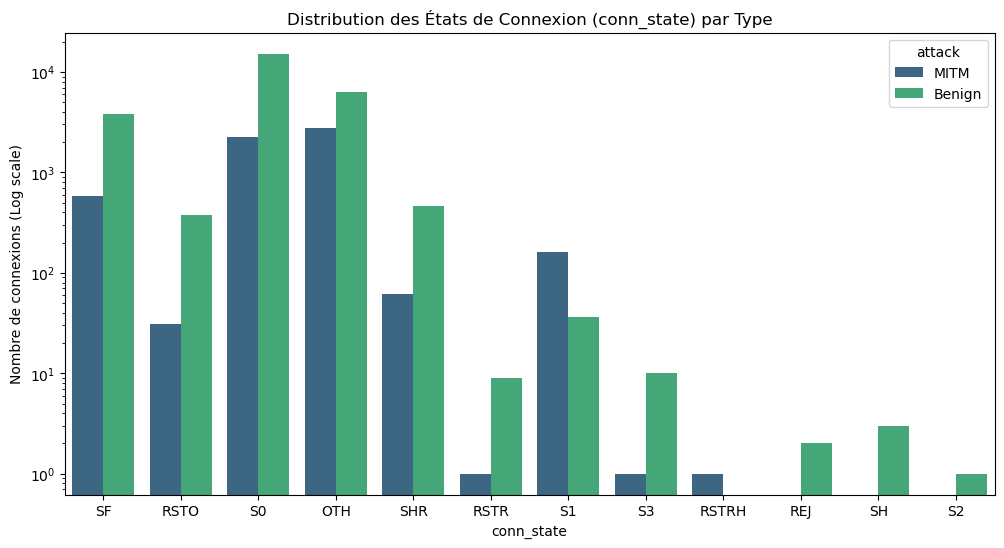

--- Détail des États suspects ---
conn_state       OTH       REJ      RSTO      RSTR     RSTRH        S0  \
attack                                                                   
Benign      0.240148  0.000076  0.014396  0.000344  0.000000  0.579846   
MITM        0.469544  0.000000  0.005289  0.000171  0.000171  0.387988   

conn_state        S1        S2        S3        SF        SH       SHR  
attack                                                                  
Benign      0.001375  0.000038  0.000382  0.145677  0.000115  0.017603  
MITM        0.027299  0.000000  0.000171  0.098789  0.000000  0.010578  


In [19]:
# Analyse des États de Connexion (conn_state)
plt.figure(figsize=(12, 6))

# On compare la distribution de conn_state entre Benign et MITM
sns.countplot(data=df, x='conn_state', hue='attack', palette='viridis')
plt.title("Distribution des États de Connexion (conn_state) par Type")
plt.yscale('log') # Échelle log car SF domine souvent, on veut voir les anomalies rares
plt.ylabel("Nombre de connexions (Log scale)")
plt.show()

print("--- Détail des États suspects ---")
print(df.groupby('attack')['conn_state'].value_counts(normalize=True).unstack().fillna(0))

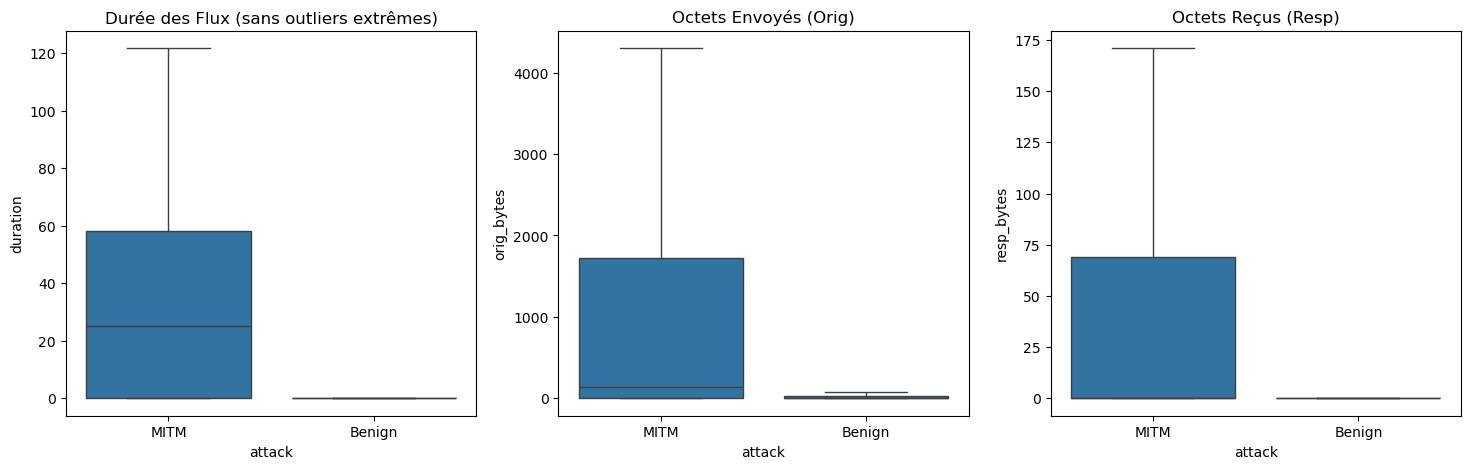

In [20]:
# Analyse des Volumes et Durées (Features Physiques)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Durée
sns.boxplot(data=df, x='attack', y='duration', ax=axes[0], showfliers=False)
axes[0].set_title("Durée des Flux (sans outliers extrêmes)")

# 2. Bytes Envoyés (Source)
sns.boxplot(data=df, x='attack', y='orig_bytes', ax=axes[1], showfliers=False)
axes[1].set_title("Octets Envoyés (Orig)")

# 3. Bytes Reçus (Réponse)
sns.boxplot(data=df, x='attack', y='resp_bytes', ax=axes[2], showfliers=False)
axes[2].set_title("Octets Reçus (Resp)")

plt.show()

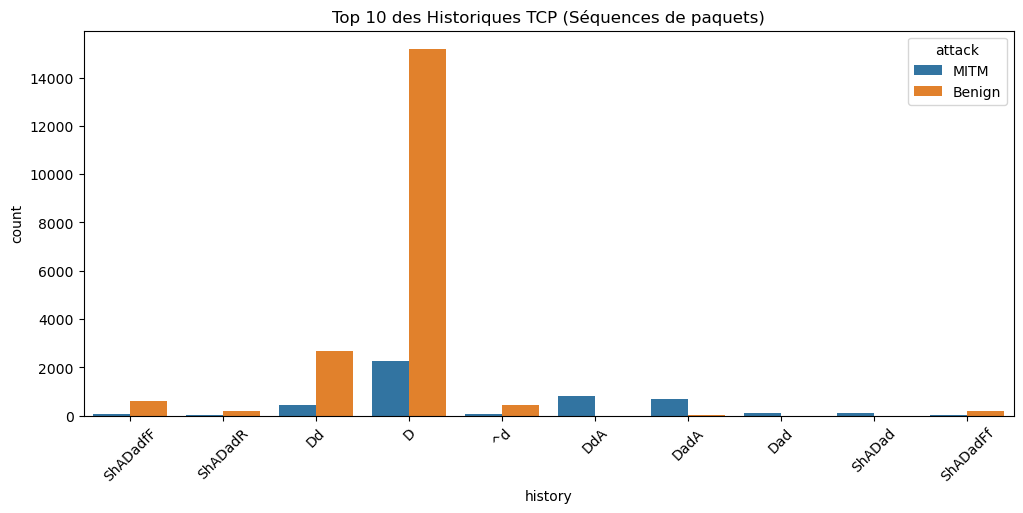

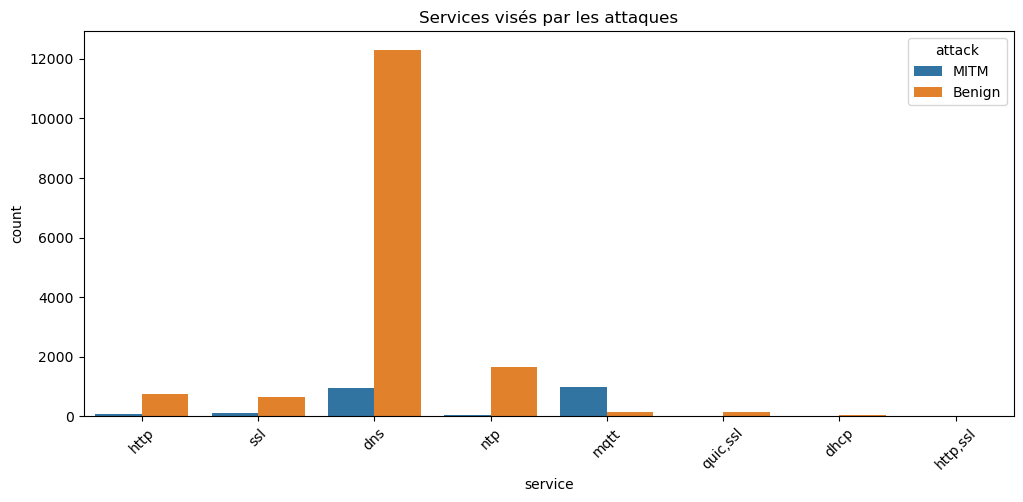

In [21]:
# Analyse des Services et de l'Historique TCP
# Top 10 des historiques TCP pour voir si des motifs d'attaque émergent
top_history = df['history'].value_counts().head(10).index

plt.figure(figsize=(12, 5))
sns.countplot(data=df[df['history'].isin(top_history)], x='history', hue='attack')
plt.title("Top 10 des Historiques TCP (Séquences de paquets)")
plt.xticks(rotation=45)
plt.show()

# Analyse des Services (MQTT, DNS, HTTP...)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='service', hue='attack')
plt.title("Services visés par les attaques")
plt.xticks(rotation=45)
plt.show()

### Création des Features

<div style="background-color: #f4f6f7; border-left: 6px solid #34495e; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">
        Le code ci-dessus transforme nos logs bruts en <b>profils comportementaux</b> agrégés par fenêtres de 10 secondes. Plutôt que de regarder chaque paquet, nous modélisons le comportement global d'une adresse IP source (<code>id.orig_h</code>). Voici les trois grandes familles de variables (features) que nous avons créées :
    </p>
    <ul style="font-size: 14px; color: #4d5656; line-height: 1.7;">
        <li>
            <strong style="color: #2980b9;">1. La Volumétrie Temporelle :</strong> 
            <code style="background-color: #ebedef; padding: 2px 6px; border-radius: 4px;">conn_count</code>, <code style="background-color: #ebedef; padding: 2px 6px; border-radius: 4px;">total_orig_bytes</code>. Ces métriques mesurent la quantité de trafic générée. Une explosion soudaine du nombre de connexions (conn_count) est un indicateur classique d'attaque par déni de service (DoS) ou de balayage réseau (Scan).
        </li>
        <li>
            <strong style="color: #2980b9;">2. Les États de Connexion TCP (Flags) :</strong> 
            Nous comptabilisons l'état dans lequel les connexions se terminent. 
            <ul style="margin-top: 5px; margin-bottom: 5px;">
                <li><code style="background-color: #ebedef; padding: 2px 6px; border-radius: 4px;">SF</code> : Connexion normale et réussie.</li>
                <li><code style="background-color: #fadbd8; color: #c0392b; padding: 2px 6px; border-radius: 4px;">OTH</code> : Trafic au milieu du flux sans poignée de main (handshake) initiale. C'est un indicateur <b>très fort</b> d'interception de trafic (MITM) ou d'usurpation.</li>
            </ul>
        </li>
        <li>
            <strong style="color: #2980b9;">3. Les Ratios (Robustesse) :</strong> 
            Les algorithmes de Machine Learning sont plus performants avec des proportions qu'avec des valeurs absolues. 
            <code style="background-color: #ebedef; padding: 2px 6px; border-radius: 4px;">ratio_OTH</code> mesure le pourcentage de connexions anormales. <code style="background-color: #ebedef; padding: 2px 6px; border-radius: 4px;">byte_asymmetry</code> calcule le ratio entre l'envoi et la réception, ce qui est redoutable pour détecter une exfiltration de données cachée (où l'attaquant envoie beaucoup de commandes sans attendre de réponse).
        </li>
    </ul>
    <div style="background-color: #d5f5e3; border-left: 4px solid #27ae60; padding: 10px 15px; margin-top: 15px; border-radius: 4px;">
        <span style="color: #1e8449; font-size: 13px;">
            <b> Pourquoi isoler MQTT (Port 1883) ?</b> Dans un contexte IIoT, le protocole MQTT est le cœur des communications entre les capteurs. Créer une variable spécifique <code>is_mqtt</code> aide le modèle à distinguer les cyberattaques ciblant directement les processus industriels.
        </span>
    </div>
</div>

In [22]:
import pandas as pd
import numpy as np

def create_advanced_conn_features(df_conn, window_size_sec=10):
    """
    Transforme les logs de connexion bruts en statistiques agrégées par fenêtre temporelle.
    Focus sur: OTH, S1, Ratios et Volumétrie.
    """
    print(" Démarrage du Feature Engineering Avancé...")
    
    df = df_conn.copy()
    
    # 1. Préparation des colonnes booléennes (One-Hot manuel pour aggregation)
    # On cible spécifiquement les états discriminants trouvés dans l'EDA
    df['is_OTH'] = (df['conn_state'] == 'OTH').astype(int)
    df['is_S0']  = (df['conn_state'] == 'S0').astype(int)
    df['is_S1']  = (df['conn_state'] == 'S1').astype(int)
    df['is_SF']  = (df['conn_state'] == 'SF').astype(int)
    
    # Indicateur de trafic MQTT (Port 1883) car c'est un vecteur d'attaque IIoT
    df['is_mqtt'] = ((df['id.resp_p'] == 1883) | (df['service'] == 'mqtt')).astype(int)
    
    # 2. Création de la clé temporelle (Window ID)
    # On aligne le temps sur des fenêtres de X secondes (ex: 10s)
    df['time_window'] = (df['ts'] // window_size_sec).astype(int)
    
    # 3. Agrégation par IP Source et par Fenêtre
    # On groupe par 'id.orig_h' (l'appareil qui émet)
    agg_rules = {
        'uid': 'count',              # Nombre total de connexions dans la fenêtre
        'is_OTH': 'sum',             # Nombre de connexions OTH
        'is_S0': 'sum',              # Nombre de connexions S0
        'is_S1': 'sum',              # Nombre de connexions S1
        'is_SF': 'sum',              # Nombre de connexions SF
        'is_mqtt': 'sum',            # Activité MQTT
        'duration': 'mean',          # Durée moyenne
        'orig_bytes': 'sum',         # Total octets envoyés
        'resp_bytes': 'sum',         # Total octets reçus
        'missed_bytes': 'sum'        # Paquets perdus (Indicateur fort MITM)
    }
    
    grouped = df.groupby(['id.orig_h', 'time_window']).agg(agg_rules)
    
    # Renommage des colonnes pour clarté
    grouped = grouped.rename(columns={
        'uid': 'conn_count',
        'is_OTH': 'count_OTH',
        'is_S0': 'count_S0',
        'is_S1': 'count_S1',
        'is_SF': 'count_SF',
        'duration': 'avg_duration',
        'orig_bytes': 'total_orig_bytes',
        'resp_bytes': 'total_resp_bytes',
        'missed_bytes': 'total_missed_bytes'
    })
    
    # 4. Feature Engineering de Second Niveau (Ratios)
    # Les ratios sont plus robustes que les nombres absolus
    grouped['ratio_OTH'] = grouped['count_OTH'] / grouped['conn_count']
    grouped['ratio_S0']  = grouped['count_S0'] / grouped['conn_count']
    grouped['ratio_S1']  = grouped['count_S1'] / grouped['conn_count']
    
    # Ratio de succès (SF / Total)
    grouped['ratio_success'] = grouped['count_SF'] / grouped['conn_count']
    
    # Ratio d'asymétrie (Upload / Download) - Utile pour l'exfiltration
    grouped['byte_asymmetry'] = grouped['total_orig_bytes'] / (grouped['total_resp_bytes'] + 1)
    
    print(f" Features générées. Shape agrégé : {grouped.shape}")
    return grouped.reset_index()

# --- EXÉCUTION ---
# Chargez votre dataset fusionné précédent
df_final_conn = pd.read_csv("dataset_final_conn.csv")

# Générez les nouvelles features (Window = 10s, ajustez selon votre dataset principal)
df_features_new = create_advanced_conn_features(df_final_conn, window_size_sec=10)

# Affichage pour vérification
print("\n--- Aperçu des Nouvelles Features ---")
display(df_features_new.head())

# Vérification de la corrélation avec l'attaque (si on avait le label ici, mais on l'a agrégé)
# On peut vérifier quelles IPs ont le plus de ratio_OTH
print("\n--- Top IPs avec fort taux OTH (Suspect MITM) ---")
print(df_features_new.sort_values(by='ratio_OTH', ascending=False)[['id.orig_h', 'ratio_OTH', 'count_S1']].head(10))

 Démarrage du Feature Engineering Avancé...
 Features générées. Shape agrégé : (15476, 15)

--- Aperçu des Nouvelles Features ---


,id.orig_h,time_window,conn_count,count_OTH,count_S0,count_S1,count_SF,is_mqtt,avg_duration,total_orig_bytes,total_resp_bytes,total_missed_bytes,ratio_OTH,ratio_S0,ratio_S1,ratio_success,byte_asymmetry
0,0.0.0.0,173948073,1,0,1,0,0,0,0.017883,616.0,0.0,0,0.0,1.0,0.0,0.0,616.0
1,0.0.0.0,175742737,1,0,1,0,0,0,114.624736,2100.0,0.0,0,0.0,1.0,0.0,0.0,2100.0
2,0.0.0.0,175742757,1,0,1,0,0,0,46.755871,600.0,0.0,0,0.0,1.0,0.0,0.0,600.0
3,0.0.0.0,175742777,1,0,1,0,0,0,105.910429,1800.0,0.0,0,0.0,1.0,0.0,0.0,1800.0
4,0.0.0.0,175742818,1,0,1,0,0,0,13.831724,1500.0,0.0,0,0.0,1.0,0.0,0.0,1500.0



--- Top IPs avec fort taux OTH (Suspect MITM) ---
                       id.orig_h  ratio_OTH  count_S1
15475  fe80::dea6:32ff:fedc:2846        1.0         0
12336               192.168.1.55        1.0         0
6087                192.168.1.11        1.0         0
6088                192.168.1.11        1.0         0
6089                192.168.1.11        1.0         0
6090                192.168.1.11        1.0         0
6091                192.168.1.11        1.0         0
6092                192.168.1.11        1.0         0
6094                192.168.1.11        1.0         0
6085                192.168.1.11        1.0         0


In [23]:
import pandas as pd
import numpy as np

df_main = pd.read_csv("mitm_dataset.csv") # Utilisez le dataset fenêtré ou non, selon votre choix pour le modèle
df_zeek = df_features_new.copy() # Le résultat du feature engineering précédent

# --- CONFIGURATION ---
# Noms exacts issus de votre extrait
MAIN_IP_COL = 'general_ip'
MAIN_TIME_COL = 'timestamp'
WINDOW_SIZE = 10  # Doit être STRICTEMENT identique à celui utilisé pour Zeek

# 1. Chargement des Datasets
# df_main = pd.read_csv("mitm_dataset.csv") 
# df_zeek = df_features_new.copy() 

print(" Démarrage de la fusion...")
print(f"Shape Main (Avant) : {df_main.shape}")

# 2. CONVERSION TEMPORELLE (CRITIQUE)
# On convertit le format "2025-01-27 16:40:51..." en Timestamp UNIX (Secondes)
# 'coerce' gère les erreurs, 'utc=True' est important car vos logs ont '+00:00'
df_main['temp_timestamp_obj'] = pd.to_datetime(df_main[MAIN_TIME_COL], utc=True, errors='coerce')

# Conversion en secondes (float)
# On convertit en entiers nanosecondes puis on divise par 10^9 pour avoir des secondes
df_main['unix_timestamp'] = df_main['temp_timestamp_obj'].astype('int64') // 10**9

# Vérification rapide (On doit voir des nombres comme 173799...)
print(f"Exemple Timestamp converti : {df_main['unix_timestamp'].iloc[0]}")

# 3. CRÉATION DES CLÉS DE JOINTURE
# Clé Fenêtre (Main)
df_main['join_window'] = (df_main['unix_timestamp'] // WINDOW_SIZE).astype(int)
# Clé Fenêtre (Zeek)
df_zeek['time_window'] = df_zeek['time_window'].astype(int)

# Clé IP (Nettoyage des espaces pour être sûr)
df_main['join_ip'] = df_main[MAIN_IP_COL].astype(str).str.strip()
df_zeek['join_ip_zeek'] = df_zeek['id.orig_h'].astype(str).str.strip()

# 4. LA FUSION (LEFT JOIN)
# On garde 100% de df_main. On ajoute les infos Zeek si l'IP et l'Heure correspondent.
df_merged = pd.merge(
    df_main,
    df_zeek,
    left_on=['join_ip', 'join_window'],      # Clés du Main
    right_on=['join_ip_zeek', 'time_window'], # Clés du Zeek
    how='left'
)

# 5. REMPLISSAGE DES VALEURS MANQUANTES (Gestion Scientifique)
# Si Zeek n'a pas de données pour cette IP à cette seconde, c'est qu'il n'y a pas eu d'activité bas niveau (ou filtrée).
# On remplit les features Zeek par 0.
zeek_features_cols = [
    'conn_count', 'count_OTH', 'count_S0', 'count_S1', 'count_SF', 
    'is_mqtt', 'avg_duration', 'total_orig_bytes', 'total_resp_bytes', 
    'total_missed_bytes', 'ratio_OTH', 'ratio_S0', 'ratio_S1', 
    'ratio_success', 'byte_asymmetry'
]

# On vérifie que les colonnes existent bien après le merge avant de fillna
cols_to_fill = [col for col in zeek_features_cols if col in df_merged.columns]
df_merged[cols_to_fill] = df_merged[cols_to_fill].fillna(0)

# 6. NETTOYAGE FINAL
# On supprime les colonnes temporaires de jointure pour laisser le dataset propre
drop_cols = ['temp_timestamp_obj', 'unix_timestamp', 'join_window', 'join_ip', 
             'join_ip_zeek', 'time_window', 'id.orig_h']
df_merged = df_merged.drop(columns=drop_cols, errors='ignore')

print("-" * 30)
print(" FUSION RÉUSSIE !")
print(f"Shape Final : {df_merged.shape}")
print("   (Le nombre de lignes doit être identique au Shape Main Avant)")

# Vérification d'un échantillon enrichi (Lignes où on a trouvé des infos Zeek)
sample_enriched = df_merged[df_merged['conn_count'] > 0].head(5)
if not sample_enriched.empty:
    print("\n Exemple de lignes enrichies avec Zeek :")
    display(sample_enriched[[MAIN_IP_COL, 'conn_count', 'ratio_OTH', 'total_orig_bytes']])
else:
    print("\n Attention : Aucune correspondance trouvée. Vérifiez que les dates des deux fichiers couvrent la même période.")

# Sauvegarde
df_merged.to_csv("Final_Dataset_Enriched.csv", index=False)

 Démarrage de la fusion...
Shape Main (Avant) : (969304, 15)
Exemple Timestamp converti : 1737996051
------------------------------
 FUSION RÉUSSIE !
Shape Final : (969304, 30)
   (Le nombre de lignes doit être identique au Shape Main Avant)

 Exemple de lignes enrichies avec Zeek :


,general_ip,conn_count,ratio_OTH,total_orig_bytes
0,192.168.1.15,1.0,1.0,5199.0
1,192.168.1.14,1.0,1.0,5006.0
2,192.168.1.14,1.0,1.0,5006.0
3,192.168.1.12,1.0,1.0,2322.0
4,192.168.1.19,2.0,1.0,10289.0


# Exploratory Data Analysis

<div style="background-color: #f4f9f9; border-left: 6px solid #3498db; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-bottom: 20px; margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #34495e;">
        <strong style="color: #3498db;">Objectif de cette étape :</strong><br>
        Avant de plonger dans l'apprentissage automatique, il est indispensable de comprendre la "physionomie" de notre jeu de données. L'Analyse Exploratoire (EDA) nous permet d'inspecter visuellement et statistiquement la qualité des données que nous venons d'ingérer.
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #34495e; margin-bottom: 5px;">Dans cette cellule, nous nous concentrons sur la cartographie de notre variable cible (<code>Label</code>) :</p>
    <ul style="font-size: 14px; color: #34495e; line-height: 1.7; margin-bottom: 15px;">
        <li><strong style="color: #2471a3;">Audit de la Distribution :</strong> Le code calcule le volume exact et le pourcentage de trafic légitime (<i>Benign</i>) par rapport aux différentes catégories d'attaques.</li>
        <li><strong style="color: #2471a3;">Visualisation des Proportions :</strong> Le graphique à barres généré via la bibliothèque <i>Seaborn</i> offre une vue instantanée de la composition de notre dataset.</li>
    </ul>
    <div style="background-color: #eaf2f8; border: 1px solid #a9cce3; padding: 10px 15px; border-radius: 4px;">
        <span style="color: #154360; font-size: 13px;">
            <b>⚠️ L'enjeu du "Class Imbalance" (Déséquilibre des classes) :</b> En cybersécurité, le trafic normal représente souvent la quasi-totalité des flux. Si notre graphique montre une domination écrasante de la classe "Normal", cela nous alerte. Un modèle entraîné sur des données trop déséquilibrées risque d'être biaisé (il prédira toujours "Normal" pour avoir un bon score). Cette étape nous permet de décider s'il faudra appliquer des techniques de rééquilibrage plus tard.
        </span>
    </div>
</div>

In [24]:
# --- CHARGEMENT ET DÉFINITION DES VARIABLES ---
data = pd.read_csv("Final_Dataset_Enriched.csv")

# Conversion du timestamp pour le fenêtrage futur
# Utilisation de format='ISO8601' pour gérer les différents formats de timestamp avec timezone
data['timestamp'] = pd.to_datetime(data['timestamp'], format='ISO8601')

# Définition des groupes de colonnes pour faciliter le travail
zeek_features = [
    'conn_count', 'count_OTH', 'count_S0', 'count_S1', 'count_SF', 
    'is_mqtt', 'avg_duration', 'total_orig_bytes', 'total_resp_bytes', 
    'total_missed_bytes', 'ratio_OTH', 'ratio_S0', 'ratio_S1', 
    'ratio_success', 'byte_asymmetry'
]

# Nettoyage initial des nouvelles variables (Gestion des infinis créés par les divisions)
# On remplace inf par NaN, puis on remplit par 0
data[zeek_features] = data[zeek_features].replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"Dataset chargé : {data.shape}")
print("Colonnes Zeek prêtes :", zeek_features)

Dataset chargé : (969304, 30)
Colonnes Zeek prêtes : ['conn_count', 'count_OTH', 'count_S0', 'count_S1', 'count_SF', 'is_mqtt', 'avg_duration', 'total_orig_bytes', 'total_resp_bytes', 'total_missed_bytes', 'ratio_OTH', 'ratio_S0', 'ratio_S1', 'ratio_success', 'byte_asymmetry']


In [25]:
# Infos sur data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969304 entries, 0 to 969303
Data columns (total 30 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   timestamp            969304 non-null  datetime64[ns, UTC]
 1   AttackType           969304 non-null  object             
 2   general_device_name  969304 non-null  object             
 3   general_application  969304 non-null  object             
 4   general_ip           969304 non-null  object             
 5   general_full_id      969304 non-null  object             
 6   general_mac          969304 non-null  object             
 7   mqtt_retained        969304 non-null  bool               
 8   mqtt_qos             969304 non-null  int64              
 9   mqtt_message_value   964552 non-null  object             
 10  mqtt_topic           969304 non-null  object             
 11  mqtt_message_id      969304 non-null  int64              
 12  mq

In [26]:
# Dimensions
print(f"Le nombre de Colonnes est : {data.shape[1]}")
print(f"Le nombre de Lignes est : {data.shape[0]}")

Le nombre de Colonnes est : 30
Le nombre de Lignes est : 969304


In [27]:
# Types des variables
data.dtypes

timestamp              datetime64[ns, UTC]
AttackType                          object
general_device_name                 object
general_application                 object
general_ip                          object
general_full_id                     object
general_mac                         object
mqtt_retained                         bool
mqtt_qos                             int64
mqtt_message_value                  object
mqtt_topic                          object
mqtt_message_id                      int64
mqtt_message_type                   object
mqtt_duplicate                        bool
target                              object
conn_count                         float64
count_OTH                          float64
count_S0                           float64
count_S1                           float64
count_SF                           float64
is_mqtt                            float64
avg_duration                       float64
total_orig_bytes                   float64
total_resp_

In [28]:
# Valeurs manquantes par colonne (counts & %)
missing_counts = data.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct %': missing_pct})
display(missing_df[missing_df['missing_count'] > 0])

,missing_count,missing_pct %
mqtt_message_value,4752,14.83


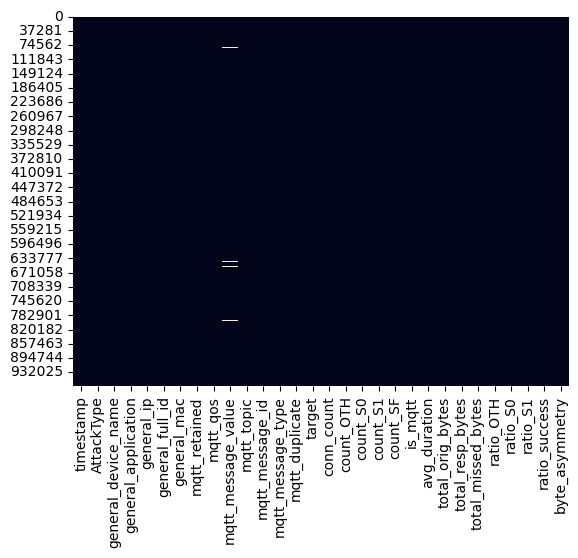

In [29]:
# Missing values
data.isna().sum()
sns.heatmap(data.isna(), cbar=False)
plt.show()

In [30]:
# Duplicates values 
data.duplicated().sum()

3283

In [31]:
# Unicité et incohérences pour (MAC, IP, topic)
cols_pair = ['general_mac', 'general_ip', 'mqtt_topic']
for c in cols_pair:
    if c not in data.columns:
        raise KeyError(f"Colonne attendue manquante: {c}")

# Regroupement par (MAC -> liste d'IPs distincts)
mac_to_ips = data.groupby('general_mac')['general_ip'].nunique().reset_index().rename(columns={'general_ip':'unique_ip_count'})
print("MAC -> nombre d'IP distinctes (quelques exemples) :")
display(mac_to_ips.sort_values('unique_ip_count', ascending=False).head(20))

# IP -> nombre de MAC distincts
ip_to_macs = data.groupby('general_ip')['general_mac'].nunique().reset_index().rename(columns={'general_mac':'unique_mac_count'})
print("IP -> nombre de MAC distincts (quelques exemples) :")
display(ip_to_macs.sort_values('unique_mac_count', ascending=False).head(20))

# Topic mapping (device/topic)
device_topic = data.groupby(['general_device_name','mqtt_topic']).size().reset_index(name='count')
print("Exemples Device -> Topic :")
display(device_topic.head(20))

MAC -> nombre d'IP distinctes (quelques exemples) :


,general_mac,unique_ip_count
0,08:B6:1F:81:D2:CC,1
1,08:B6:1F:82:12:30,1
2,08:B6:1F:82:1C:3C,1
3,08:B6:1F:82:27:D0,1
4,08:B6:1F:82:2B:1C,1
5,08:B6:1F:82:EE:44,1
6,08:B6:1F:82:EE:C4,1
7,08:B6:1F:82:EE:CC,1
8,08:B6:1F:82:EF:30,1
9,08:B6:1F:83:25:98,1


IP -> nombre de MAC distincts (quelques exemples) :


,general_ip,unique_mac_count
0,192.168.1.10,1
1,192.168.1.11,1
2,192.168.1.12,1
3,192.168.1.13,1
4,192.168.1.14,1
5,192.168.1.15,1
6,192.168.1.16,1
7,192.168.1.17,1
8,192.168.1.18,1
9,192.168.1.19,1


Exemples Device -> Topic :


,general_device_name,mqtt_topic,count
0,ard-w-01,iiot/weather/analogtemp,43427
1,ard-w-01,iiot/weather/bmp180/altitude,43427
2,ard-w-01,iiot/weather/bmp180/pressure,43427
3,ard-w-01,iiot/weather/bmp180/temp,43427
4,ard-w-01,iiot/weather/humidity,43427
5,ard-w-01,iiot/weather/lineartemp,43427
6,ard-w-01,iiot/weather/temp,43997
7,ard-w-02,iiot/soil,47232
8,ard-w-03,iiot/sound/big,47970
9,ard-w-03,iiot/sound/small,47389


## Analyse du volume et équilibre des classes

Valeurs de target :


target
benign    874923
attack     94381
Name: count, dtype: int64

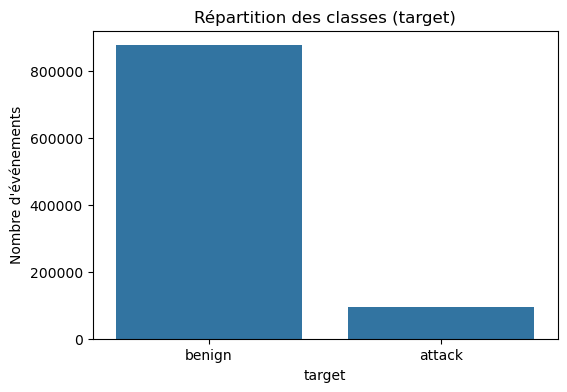


Ratio (%) des classes :
target
benign    90.26
attack     9.74
Name: count, dtype: float64


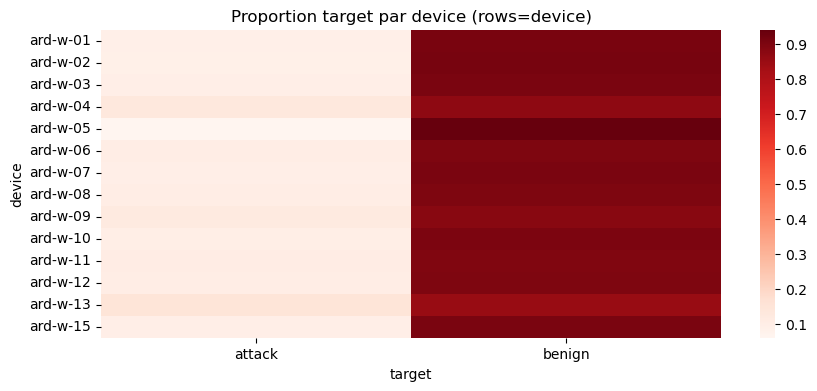

In [32]:
# Balance des classes
if 'target' not in data.columns:
    raise KeyError("Colonne 'target' manquante dans le dataset")

counts = data['target'].value_counts()
print("Valeurs de target :")
display(counts)

# Bar chart Benign vs Attack
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='target', order=counts.index)
plt.title("Répartition des classes (target)")
plt.ylabel("Nombre d'événements")
plt.show()

# Ratio en %
print("\nRatio (%) des classes :")
print((counts / counts.sum() * 100).round(2))

# Heatmap de classes par device (pour détecter imbalance par device)
pivot = pd.crosstab(data['general_device_name'], data['target'])
# Normaliser par device pour voir proportions
pivot_prop = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
plt.figure(figsize=(10, max(4, 0.25*len(pivot_prop))))
sns.heatmap(pivot_prop, cmap="Reds", cbar=True)
plt.title("Proportion target par device (rows=device)")
plt.xlabel("target")
plt.ylabel("device")
plt.show()

## Analyse des Variables (Univariée)

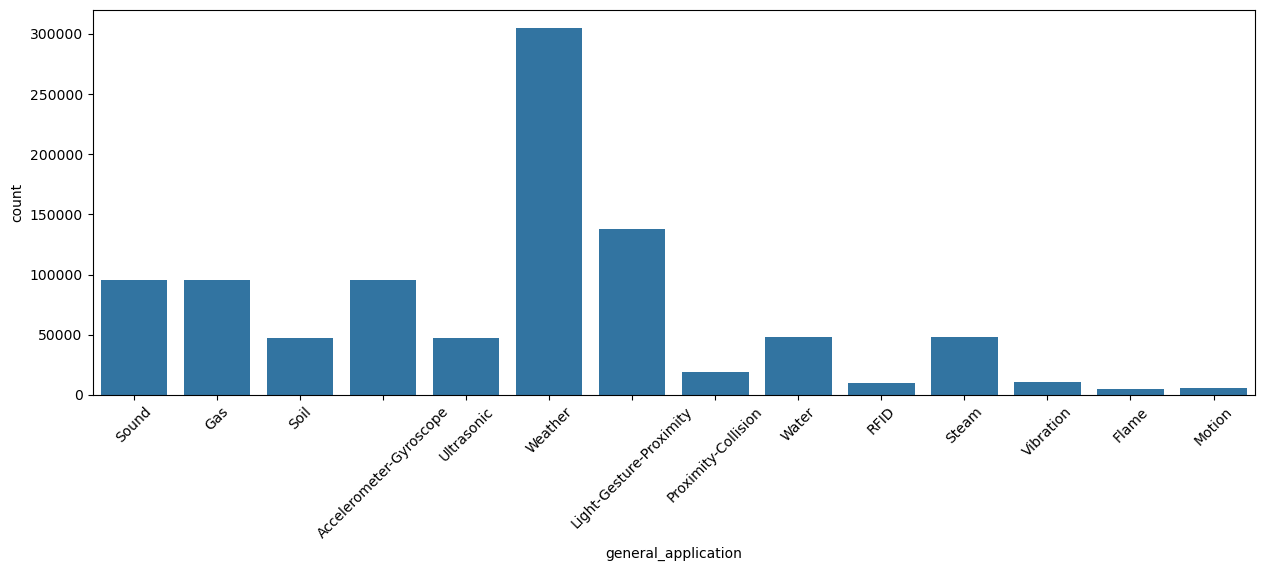

In [33]:
# Categorical Variables
cat_cols = ['general_device_name', 'general_application', 'mqtt_topic', 'mqtt_message_type']

plt.figure(figsize=(15,5))
sns.countplot(data=data, x='general_application')
plt.xticks(rotation=45)
plt.show()

## Analyse Temporelle

C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\2656279991.py:11: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  data['ts_second'] = data[ts].dt.floor('S')
C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\2656279991.py:12: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  data['ts_minute'] = data[ts].dt.floor('T')


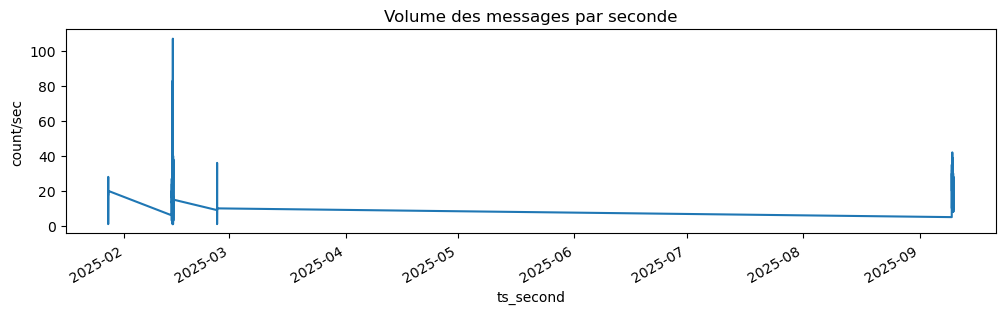

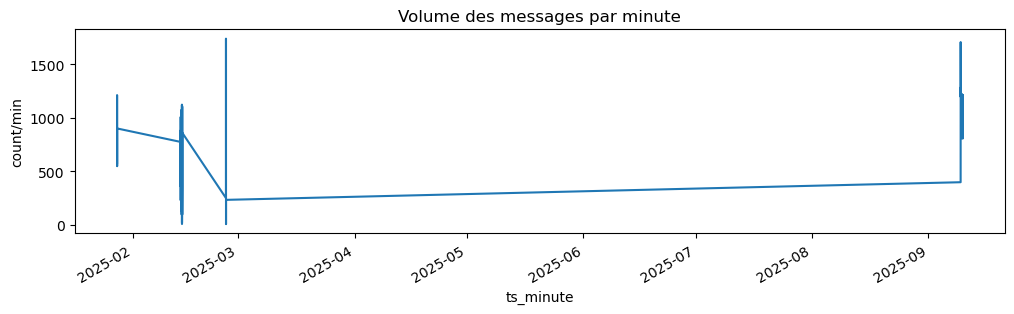

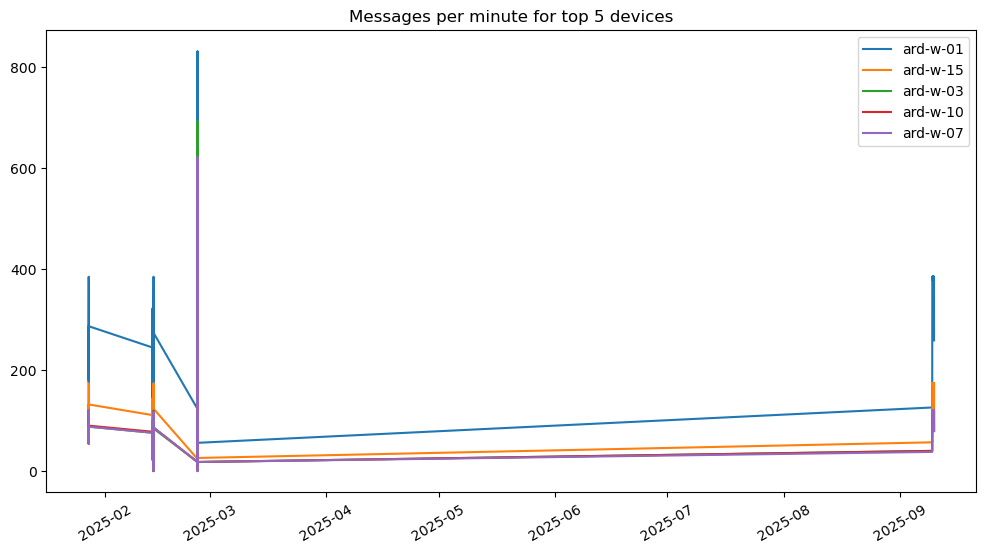

In [34]:
# Cell 8 — Analyse temporelle
ts = 'timestamp'
if ts not in data.columns:
    raise KeyError("Colonne timestamp manquante pour l'analyse temporelle.")

# Convert timestamp column to datetime with format='ISO8601' to handle various ISO formats including timezone
data[ts] = pd.to_datetime(data[ts], format='ISO8601')  # Changed to use ISO8601 format

# Agg par seconde, minute
data = data.sort_values(ts)
data['ts_second'] = data[ts].dt.floor('S')
data['ts_minute'] = data[ts].dt.floor('T')

# Distribution par seconde (global)
per_second = data.groupby('ts_second').size()
plt.figure(figsize=(12,3))
per_second.plot()
plt.title("Volume des messages par seconde")
plt.ylabel("count/sec")
plt.show()

# Distribution par minute
per_minute = data.groupby('ts_minute').size()
plt.figure(figsize=(12,3))
per_minute.plot()
plt.title("Volume des messages par minute")
plt.ylabel("count/min")
plt.show()

# Courbes pour quelques capteurs (top 5)
top5 = data['general_device_name'].value_counts().head(5).index.tolist()
plt.figure(figsize=(12,6))
for dev in top5:
    series = data[data['general_device_name']==dev].groupby('ts_minute').size()
    series = series.reindex(data['ts_minute'].sort_values().unique(), fill_value=0)
    plt.plot(series.index, series.values, label=dev)
plt.legend()
plt.title("Messages per minute for top 5 devices")
plt.xticks(rotation=30)
plt.show()

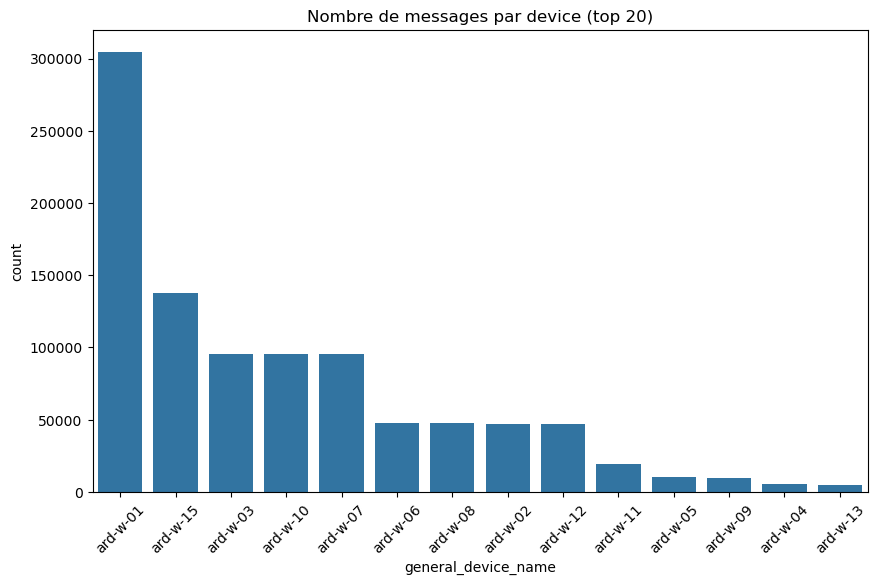

In [35]:
# Frequency of messages per device (global)
top_devices = data['general_device_name'].value_counts().head(20).index
plt.figure(figsize=(10,6))
sns.countplot(data=data[data['general_device_name'].isin(top_devices)], x='general_device_name', order=top_devices)
plt.xticks(rotation=45)
plt.title("Nombre de messages par device (top 20)")
plt.show()

## Analyse des topics MQTT

In [36]:
# Top topics & variation par target
top_topics = data['mqtt_topic'].value_counts().head(20)
print("Top 20 topics:")
display(top_topics)

Top 20 topics:


mqtt_topic
iiot/water                       48049
iiot/steam                       48024
iiot/sound/big                   47970
iiot/acceleration/xyz            47948
iiot/gas/gas                     47914
iiot/sound/small                 47389
iiot/acceleration/orientation    47375
iiot/gas/alcohol                 47328
iiot/soil                        47232
iiot/ultrasonic                  47223
iiot/light/light                 46396
iiot/light/proximity             45809
iiot/light/rgb                   45809
iiot/weather/temp                43997
iiot/weather/humidity            43427
iiot/weather/bmp180/pressure     43427
iiot/weather/lineartemp          43427
iiot/weather/bmp180/temp         43427
iiot/weather/analogtemp          43427
iiot/weather/bmp180/altitude     43427
Name: count, dtype: int64

<Figure size 1200x600 with 0 Axes>

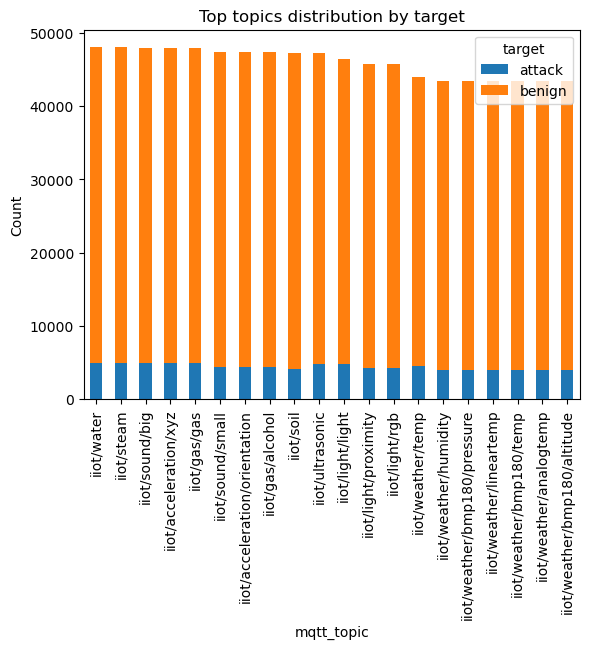

In [37]:
# Variation par target
topic_target = pd.crosstab(data['mqtt_topic'], data['target'])
# Montrer les 20 topics les plus fréquents
topic_target_top = topic_target.loc[top_topics.index]
plt.figure(figsize=(12,6))
topic_target_top.plot(kind='bar', stacked=True)
plt.title("Top topics distribution by target")
plt.ylabel("Count")
plt.legend(title='target')
plt.show()

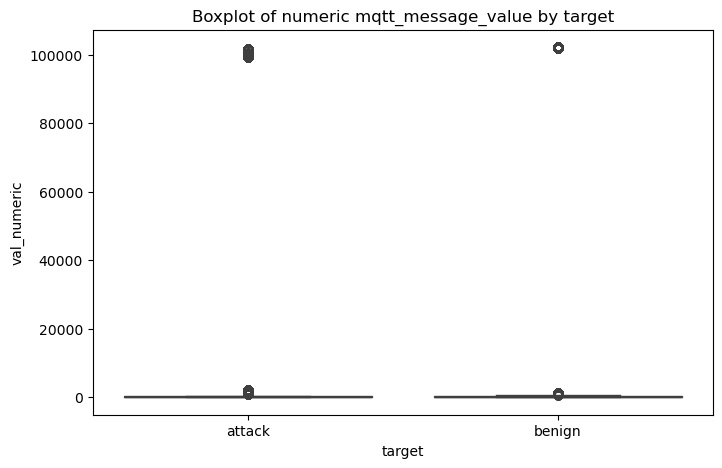

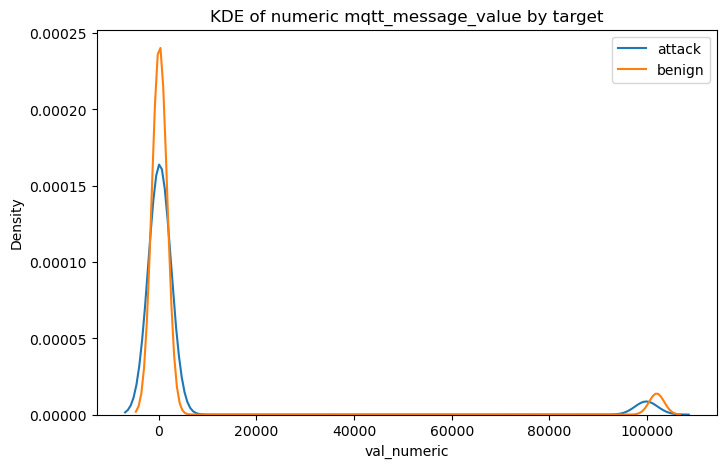

Array lengths distribution:


arr_len
3    93757
2     4736
Name: count, dtype: int64

,timestamp,AttackType,general_device_name,general_application,general_ip,general_full_id,general_mac,mqtt_retained,mqtt_qos,mqtt_message_value,...,ratio_S0,ratio_S1,ratio_success,byte_asymmetry,ts_second,ts_minute,val_numeric,val_array,val_type_inferred,arr_len
31886,2025-01-27 16:18:31.617000+00:00,ARP_Spoofing,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/rgb,8C:AA:B5:8A:A9:B4,False,0,"[250.0, 339.0, 339.0]",...,0.0,0.0,0.0,1849.4,2025-01-27 16:18:31+00:00,2025-01-27 16:18:00+00:00,NaN,"[250.0, 339.0, 339.0]",array,3
32722,2025-01-27 16:18:31.902000+00:00,ARP_Spoofing,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,"[-0.74, -0.02, 2.0]",...,0.0,0.0,0.0,2057.8,2025-01-27 16:18:31+00:00,2025-01-27 16:18:00+00:00,NaN,"[-0.74, -0.02, 2.0]",array,3
32723,2025-01-27 16:18:32.717000+00:00,ARP_Spoofing,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/rgb,8C:AA:B5:8A:A9:B4,False,0,"[251.0, 340.0, 340.0]",...,0.0,0.0,0.0,1849.4,2025-01-27 16:18:32+00:00,2025-01-27 16:18:00+00:00,NaN,"[251.0, 340.0, 340.0]",array,3
31085,2025-01-27 16:18:32.917000+00:00,ARP_Spoofing,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,"[-0.74, -0.02, 2.0]",...,0.0,0.0,0.0,2057.8,2025-01-27 16:18:32+00:00,2025-01-27 16:18:00+00:00,NaN,"[-0.74, -0.02, 2.0]",array,3
32732,2025-01-27 16:18:33.694000+00:00,ARP_Spoofing,ard-w-15,Light-Gesture-Proximity,192.168.1.18,8C:AA:B5:8A:A9:B4_192.168.1.18_iiot/light/rgb,8C:AA:B5:8A:A9:B4,False,0,"[251.0, 340.0, 340.0]",...,0.0,0.0,0.0,1849.4,2025-01-27 16:18:33+00:00,2025-01-27 16:18:00+00:00,NaN,"[251.0, 340.0, 340.0]",array,3


Top 20 string values:


mqtt_message_value
Landscape Left    42957
Portrait Up        4418
DA 96 A2 EA           3
19 FB 61 B2           2
Name: count, dtype: int64

In [38]:
# Cell 12 — Préparer mqtt_message_value selon type
val_col = 'mqtt_message_value'
type_col = 'mqtt_message_type'  # attendue : numeric / array / string

# 1) Numeric detection
data['val_numeric'] = pd.to_numeric(data[val_col], errors='coerce')

# 2) Arrays detection: try to parse strings that look like lists "[x, y, z]"
import ast
def parse_array(x):
    if isinstance(x, str) and x.strip().startswith('[') and x.strip().endswith(']'):
        try:
            lst = ast.literal_eval(x)
            if isinstance(lst, (list,tuple)):
                return lst
        except:
            return np.nan
    return np.nan

data['val_array'] = data[val_col].apply(parse_array)
data['val_type_inferred'] = data['val_numeric'].notnull().map({True:'numeric'}).where(data['val_numeric'].notnull(), 
                             data['val_array'].notnull().map({True:'array'})).fillna(data.get(type_col, pd.Series(['unknown']*len(data))))

# 3) Numeric distribution (boxplot attack vs benign)
num_df = data[data['val_numeric'].notnull()].copy()
num_df['val_numeric'] = num_df['val_numeric'].astype(float)
plt.figure(figsize=(8,5))
sns.boxplot(data=num_df, x='target', y='val_numeric')
plt.title("Boxplot of numeric mqtt_message_value by target")
plt.show()

# 4) KDE (density) per target
plt.figure(figsize=(8,5))
for t in num_df['target'].unique():
    sns.kdeplot(num_df[num_df['target']==t]['val_numeric'], label=t, fill=False)
plt.title("KDE of numeric mqtt_message_value by target")
plt.legend()
plt.show()

# 5) Array parsing: examine dimension & summary stats
arrays = data[data['val_array'].notnull()].copy()
arrays['arr_len'] = arrays['val_array'].apply(lambda x: len(x) if isinstance(x,(list,tuple)) else 0)
print("Array lengths distribution:")
display(arrays['arr_len'].value_counts())
display(arrays.head())

# 6) String categories distribution
strings = data[(data['val_numeric'].isnull()) & (data['val_array'].isnull())][val_col]
print("Top 20 string values:")
display(strings.value_counts().head(20))


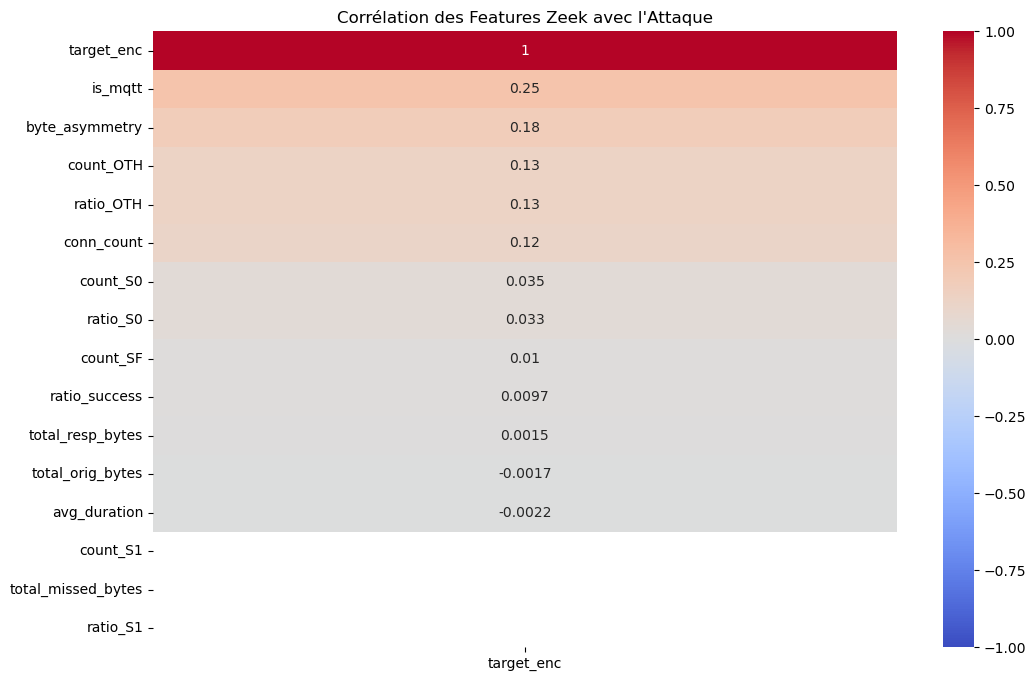

In [39]:
# --- Corrélation Features Réseau vs Target ---
plt.figure(figsize=(12, 8))

# On encode temporairement la target pour la corrélation
df_corr = data.copy()
df_corr['target_enc'] = df_corr['target'].apply(lambda x: 1 if x == 'attack' else 0)

# On sélectionne uniquement les features numériques Zeek + Target
cols_to_corr = zeek_features + ['target_enc']
corr_matrix = df_corr[cols_to_corr].corr()

sns.heatmap(corr_matrix[['target_enc']].sort_values(by='target_enc', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Corrélation des Features Zeek avec l'Attaque")
plt.show()

C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\2711183986.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y='ratio_OTH', ax=axes[0], palette='Set2')
C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\2711183986.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y='byte_asymmetry', ax=axes[1], palette='Set2')
C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\2711183986.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y='conn_count', ax=axes[2], palette='Set2')


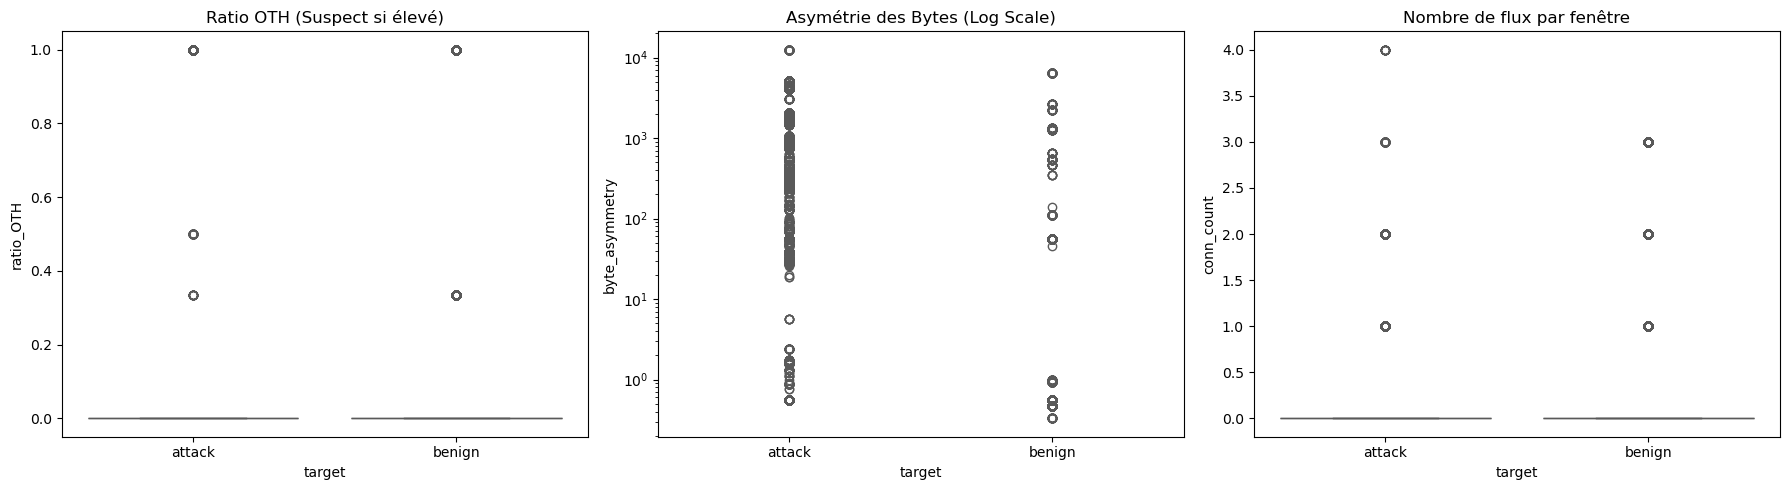

In [40]:
# --- Analyse des Signatures d'Attaque (OTH et Asymétrie) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ratio OTH (Indicateur ARP Spoofing)
sns.boxplot(data=data, x='target', y='ratio_OTH', ax=axes[0], palette='Set2')
axes[0].set_title("Ratio OTH (Suspect si élevé)")

# 2. Byte Asymmetry (Indicateur Exfiltration/Injection)
# On limite l'axe Y car l'asymétrie peut être géante
sns.boxplot(data=data, x='target', y='byte_asymmetry', ax=axes[1], palette='Set2')
axes[1].set_yscale('log') 
axes[1].set_title("Asymétrie des Bytes (Log Scale)")

# 3. Conn Count (Volume de connexions dans la fenêtre)
sns.boxplot(data=data, x='target', y='conn_count', ax=axes[2], palette='Set2')
axes[2].set_title("Nombre de flux par fenêtre")

plt.tight_layout()
plt.show()

# Agrégation (Fenetrage) de dataset

<div style="background-color: #fef9e7; border-left: 6px solid #f1c40f; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">
        <strong style="color: #b7950b;">Méthodologie : Le Fenêtrage (Windowing)</strong><br>
        Le trafic réseau est une série temporelle continue. Analyser un paquet réseau de manière isolée n'a que très peu de sens pour détecter une attaque complexe comme l'ARP Spoofing. 
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">
        Dans cette section, nous appliquons une technique de <b>Fenêtrage</b>. Nous regroupons les flux réseau sur des intervalles de temps donnés. Pour chaque fenêtre, nous calculons des métriques statistiques telles que :
    </p>
    <ul style="font-size: 14px; color: #4d5656; line-height: 1.6;">
        <li><code style="background-color: #fdebd0; padding: 2px 6px; border-radius: 4px; color: #d35400;">nbr_requests</code> : Le volume de connexions initiées (pour détecter les inondations).</li>
        <li><code style="background-color: #fdebd0; padding: 2px 6px; border-radius: 4px; color: #d35400;">byte_asymmetry</code> : Le ratio octets envoyés/reçus (pour détecter l'exfiltration).</li>
        <li><code style="background-color: #fdebd0; padding: 2px 6px; border-radius: 4px; color: #d35400;">ratio_OTH</code> : Le taux de connexions sans poignée de main TCP valide.</li>
    </ul>
</div>

In [41]:
# Préparation et Calcul des Métriques Temporelles (Inter-arrival)

# 1. Chargement
# chargez 'Final_Dataset_Enriched.csv'
df = pd.read_csv("Final_Dataset_Enriched.csv")

# Conversion Timestamp critique - Modifié pour gérer les formats avec timezone
# Utilisation de format='ISO8601' pour gérer automatiquement différents formats ISO
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')

# 2. Choix de l'Entité : ON PASSE À L'IP (Pour compatibilité Zeek)
df['entity_id'] = df['general_ip'] 

# Tri indispensable pour calculer le temps entre paquets
df = df.sort_values(['entity_id', 'timestamp'])

# 3. Calcul de l'Inter-arrival Time
# C'est le temps écoulé depuis le paquet précédent de la MÊME IP
df['inter_arrival_time'] = df.groupby('entity_id')['timestamp'].diff().dt.total_seconds()

# Gestion des NaNs (le premier paquet de chaque IP a NaN) et des gaps aberrants (>10s)
# On remplit par 0 ou la moyenne locale pour ne pas perdre la ligne, ou on filtre.
# Ici, on remplit par 0 pour garder la trace du début de fenêtre.
df['inter_arrival_time'] = df['inter_arrival_time'].fillna(0)

print(" Préparation Temporelle terminée.")
print(df[['timestamp', 'entity_id', 'inter_arrival_time']].head())

 Préparation Temporelle terminée.
                             timestamp     entity_id  inter_arrival_time
31076 2025-01-27 16:18:31.752000+00:00  192.168.1.10               0.000
31888 2025-01-27 16:18:31.768000+00:00  192.168.1.10               0.016
32720 2025-01-27 16:18:31.768000+00:00  192.168.1.10               0.000
31077 2025-01-27 16:18:31.769000+00:00  192.168.1.10               0.001
31078 2025-01-27 16:18:31.769000+00:00  192.168.1.10               0.000


In [42]:
# Définition de la Fenêtre (Alignement Zeek)
# --- FENÊTRAGE ---

# On aligne sur 10 secondes pour correspondre aux stats Zeek (ratio_OTH, etc.)
WINDOW_SIZE = '10s' 

# On crée la clé de groupement temporelle
df['time_window'] = df['timestamp'].dt.floor(WINDOW_SIZE)

print(f"Fenêtre temporelle définie sur : {WINDOW_SIZE}")

Fenêtre temporelle définie sur : 10s


In [43]:
# L'Agrégation Finale (Hybride : MQTT + Time + Zeek)
# --- AGRÉGATION INTELLIGENTE ---

# 1. Définition des règles
agg_rules = {
    # Target : On utilise une lambda pour décider si la fenêtre est une attaque
    'target': lambda x: 'attack' if 'attack' in x.values else 'benign',
    'AttackType': 'first',
    
    # Volumétrie
    'timestamp': 'count', 
    
    # MQTT
    'mqtt_duplicate': 'sum',
    'mqtt_message_id': 'nunique',
    'mqtt_topic': 'nunique',
    
    # Temporel (Votre logique)
    'inter_arrival_time': ['mean', 'std', 'min', 'max'],
    
    # Zeek (Réseau) - On prend le max pour garder la valeur constante de la fenêtre
    'conn_count': 'max',
    'count_OTH': 'max',
    'count_S0': 'max',
    'count_S1': 'max',
    'ratio_OTH': 'max',
    'ratio_S0': 'max',
    'byte_asymmetry': 'max',
    'total_missed_bytes': 'max'
}

print(" Lancement de l'agrégation...")
df_final_windowed = df.groupby(['entity_id', 'time_window']).agg(agg_rules)

# 2. Aplatissement des colonnes (Correction du nommage)
# Cette boucle crée des noms comme 'inter_arrival_time_mean' ou 'target_<lambda>'
df_final_windowed.columns = [
    f"{col[0]}_{col[1]}" if col[1] else col[0] 
    for col in df_final_windowed.columns
]

# 3. NETTOYAGE DES NOMS (C'est ici qu'on corrige le problème)
rename_dict = {
    'target_<lambda>': 'target',      
    'timestamp_count': 'nbr_requests',
    'AttackType_first': 'AttackType',
    'mqtt_duplicate_sum': 'mqtt_duplicate',
    'mqtt_message_id_nunique': 'mqtt_message_id_count',
    'mqtt_topic_nunique': 'mqtt_topic_count'
}

# On applique le renommage
df_final_windowed = df_final_windowed.rename(columns=rename_dict)

# On retire aussi les suffixes "_max" inutiles des colonnes Zeek pour faire propre
cols_zeek_clean = {col: col.replace('_max', '') for col in df_final_windowed.columns if '_max' in col}
df_final_windowed = df_final_windowed.rename(columns=cols_zeek_clean)

# 4. Finalisation
df_final_windowed = df_final_windowed.reset_index()
df_final_windowed = df_final_windowed.fillna(0)

print(f" Agrégation Terminée. Shape : {df_final_windowed.shape}")
print("Colonnes finales :", df_final_windowed.columns.tolist())

 Lancement de l'agrégation...
 Agrégation Terminée. Shape : (66846, 20)
Colonnes finales : ['entity_id', 'time_window', 'target', 'AttackType', 'nbr_requests', 'mqtt_duplicate', 'mqtt_message_id_count', 'mqtt_topic_count', 'inter_arrival_time_mean', 'inter_arrival_time_std', 'inter_arrival_time_min', 'inter_arrival_time', 'conn_count', 'count_OTH', 'count_S0', 'count_S1', 'ratio_OTH', 'ratio_S0', 'byte_asymmetry', 'total_missed_bytes']


In [44]:
# Export Final et Vérification
# Sauvegarde
OUTPUT_FILE = "mitm_dataset_hybrid.csv"
df_final_windowed.to_csv(OUTPUT_FILE, index=False)

print(f"Fichier sauvegardé : {OUTPUT_FILE}")

# Utiliser la colonne identifiée
cols_to_check = ['nbr_requests', 'inter_arrival_time_std', 'ratio_OTH_max', 'byte_asymmetry_max']
available_cols = [col for col in cols_to_check if col in df_final_windowed.columns]

print(f"Groupement par target avec colonnes disponibles: {available_cols}")
df_final_windowed.groupby('target')[available_cols].mean()

Fichier sauvegardé : mitm_dataset_hybrid.csv
Groupement par target avec colonnes disponibles: ['nbr_requests', 'inter_arrival_time_std']


,nbr_requests,inter_arrival_time_std
target,,
attack,14.449020,1389.311867
benign,14.506135,989.935482


In [45]:
# Différence attack vs benign
df_final_windowed.groupby('target')['nbr_requests'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
attack,6532.0,14.449020,18.232779,1.0,2.0,10.0,20.0,170.0
benign,60314.0,14.506135,16.244564,1.0,2.0,10.0,20.0,78.0


## EDA sur Data agregee

In [46]:
data = pd.read_csv("mitm_dataset_hybrid.csv")
data.head()

,entity_id,time_window,target,AttackType,nbr_requests,mqtt_duplicate,mqtt_message_id_count,mqtt_topic_count,inter_arrival_time_mean,inter_arrival_time_std,inter_arrival_time_min,inter_arrival_time,conn_count,count_OTH,count_S0,count_S1,ratio_OTH,ratio_S0,byte_asymmetry,total_missed_bytes
0,192.168.1.10,2025-01-27 16:18:30+00:00,attack,ARP_Spoofing,56,0,1,7,0.137089,0.357302,0.0,1.126,2.0,2.0,0.0,0.0,1.0,0.0,5062.4,0.0
1,192.168.1.10,2025-01-27 16:18:40+00:00,attack,ARP_Spoofing,63,0,1,7,0.156794,0.375550,0.0,1.115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,192.168.1.10,2025-01-27 16:18:50+00:00,attack,ARP_Spoofing,63,0,1,7,0.156429,0.377832,0.0,1.090,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,192.168.1.10,2025-01-27 16:19:00+00:00,attack,ARP_Spoofing,63,0,1,7,0.156968,0.376808,0.0,1.094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,192.168.1.10,2025-01-27 16:19:10+00:00,attack,ARP_Spoofing,70,0,1,7,0.156343,0.375716,0.0,1.094,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
# Dimensions
print(f"Le nombre de Colonnes est : {data.shape[1]}")
print(f"Le nombre de Lignes est : {data.shape[0]}")

Le nombre de Colonnes est : 20
Le nombre de Lignes est : 66846


In [48]:
# Types des variables
data.dtypes

entity_id                   object
time_window                 object
target                      object
AttackType                  object
nbr_requests                 int64
mqtt_duplicate               int64
mqtt_message_id_count        int64
mqtt_topic_count             int64
inter_arrival_time_mean    float64
inter_arrival_time_std     float64
inter_arrival_time_min     float64
inter_arrival_time         float64
conn_count                 float64
count_OTH                  float64
count_S0                   float64
count_S1                   float64
ratio_OTH                  float64
ratio_S0                   float64
byte_asymmetry             float64
total_missed_bytes         float64
dtype: object

In [49]:
# Valeurs manquantes par colonne (counts & %)
missing_counts = data.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(data) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct %': missing_pct})
display(missing_df[missing_df['missing_count'] > 0])

,missing_count,missing_pct %


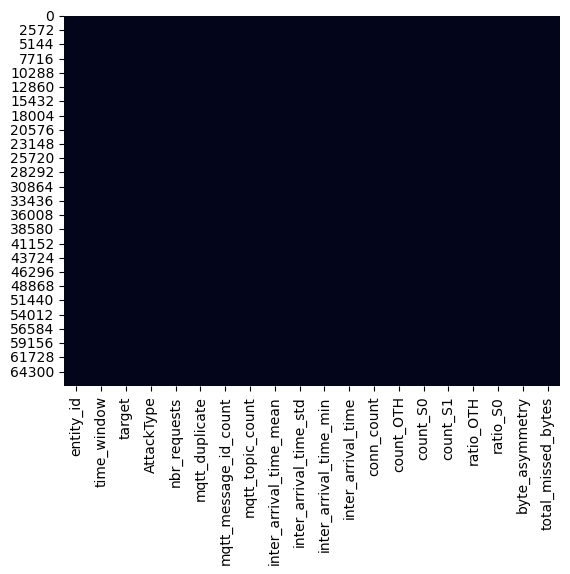

In [50]:
# Missing values
data.isna().sum()
sns.heatmap(data.isna(), cbar=False)
plt.show()

In [51]:
# Duplicates values 
data.duplicated().sum()

0

## Analyse des entités (multi-device)

In [52]:
## Nombre de devices
data['entity_id'].nunique()

14

In [53]:
## Volume par device
data['entity_id'].value_counts().head(10)

entity_id
192.168.1.10    4815
192.168.1.11    4813
192.168.1.14    4811
192.168.1.19    4811
192.168.1.15    4810
192.168.1.17    4810
192.168.1.13    4809
192.168.1.18    4805
192.168.1.16    4755
192.168.1.22    4754
Name: count, dtype: int64

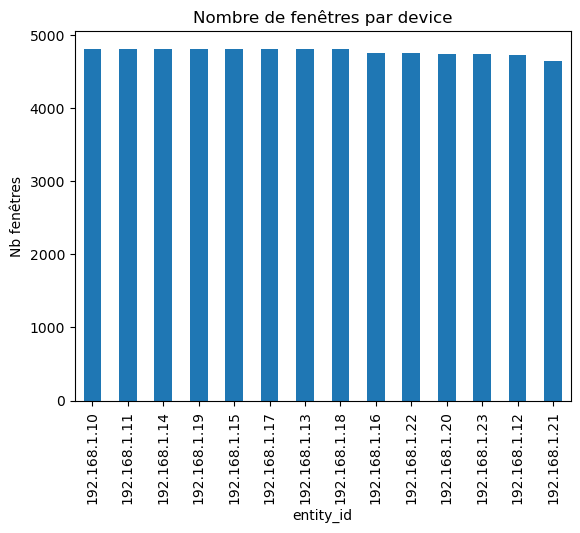

In [54]:
plt.figure()
data['entity_id'].value_counts().plot(kind='bar')
plt.title("Nombre de fenêtres par device")
plt.ylabel("Nb fenêtres")
plt.xticks(rotation=90)
plt.show()

## Analyse des classes

Valeurs de target :


target
benign    60314
attack     6532
Name: count, dtype: int64

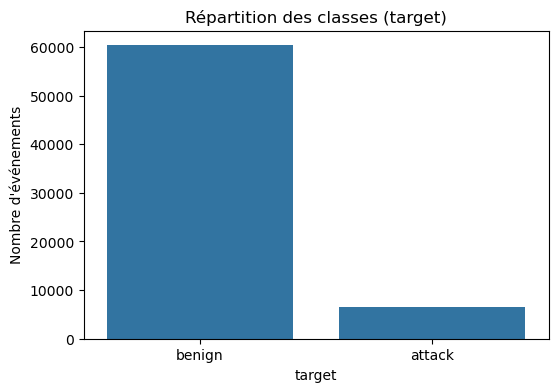


Ratio (%) des classes :
target
benign    90.23
attack     9.77
Name: count, dtype: float64


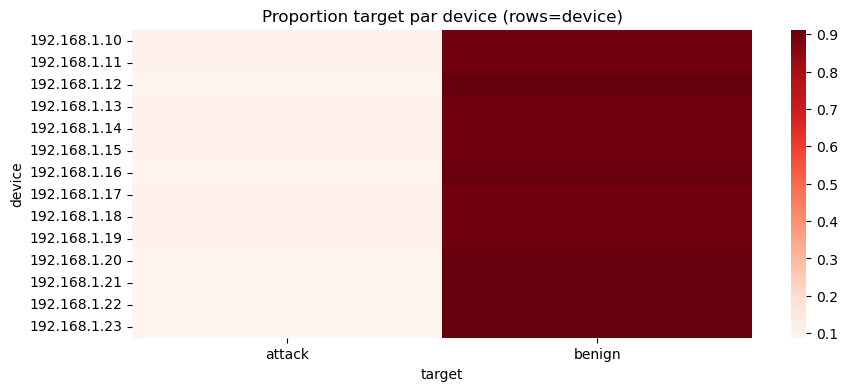

In [55]:
# Balance des classes
if 'target' not in data.columns:
    raise KeyError("Colonne 'target' manquante dans le dataset")

counts = data['target'].value_counts()
print("Valeurs de target :")
display(counts)

# Bar chart Benign vs Attack
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='target', order=counts.index)
plt.title("Répartition des classes (target)")
plt.ylabel("Nombre d'événements")
plt.show()

# Ratio en %
print("\nRatio (%) des classes :")
print((counts / counts.sum() * 100).round(2))

# Heatmap de classes par device (pour détecter imbalance par device)
pivot = pd.crosstab(data['entity_id'], data['target'])
# Normaliser par device pour voir proportions
pivot_prop = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
plt.figure(figsize=(10, max(4, 0.25*len(pivot_prop))))
sns.heatmap(pivot_prop, cmap="Reds", cbar=True)
plt.title("Proportion target par device (rows=device)")
plt.xlabel("target")
plt.ylabel("device")
plt.show()

In [56]:
# Types d’attaques
data['AttackType'].value_counts()

AttackType
Benign           60314
ARP_Spoofing      3073
IP_Spoofing       2177
Impersonation     1282
Name: count, dtype: int64

In [57]:
# Analyse de la feature clé : nbr_requests
## Distribution globale
data['nbr_requests'].describe()

count    66846.000000
mean        14.500554
std         16.449305
min          1.000000
25%          2.000000
50%         10.000000
75%         20.000000
max        170.000000
Name: nbr_requests, dtype: float64

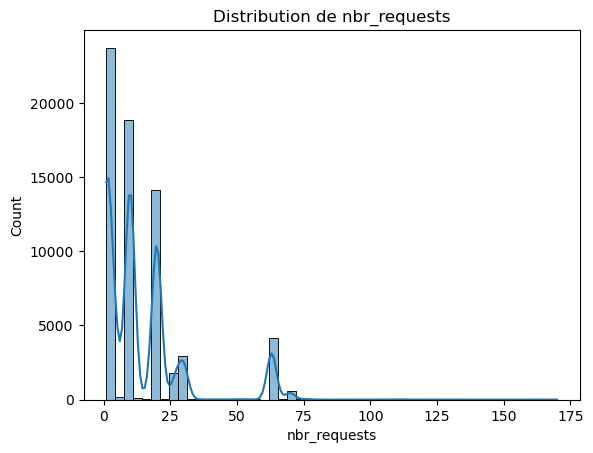

In [58]:
plt.figure()
sns.histplot(data['nbr_requests'], bins=50, kde=True)
plt.title("Distribution de nbr_requests")
plt.show()

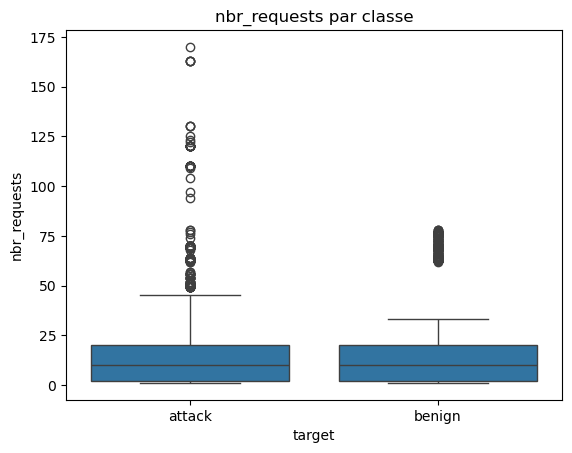

In [59]:
## Par classe
plt.figure()
sns.boxplot(x='target', y='nbr_requests', data=data)
plt.title("nbr_requests par classe")
plt.show()

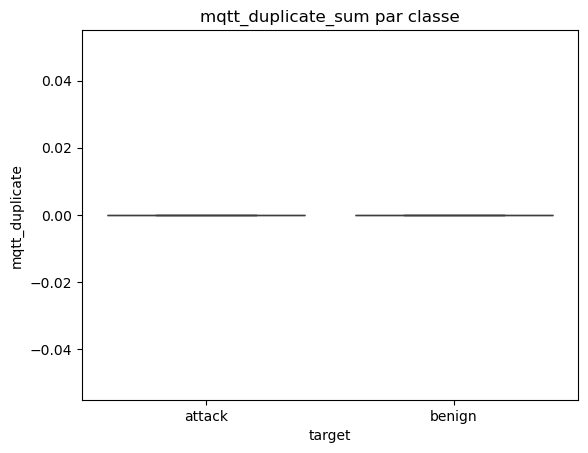

In [60]:
# Analyse des features MQTT (replay / incohérences)
## mqtt_duplicate_sum
sns.boxplot(x='target', y='mqtt_duplicate', data=data)
plt.title("mqtt_duplicate_sum par classe")
plt.show()

## Analyse temporelle avancée

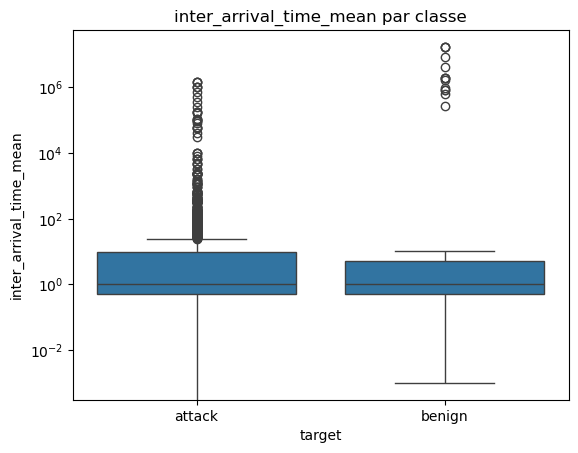

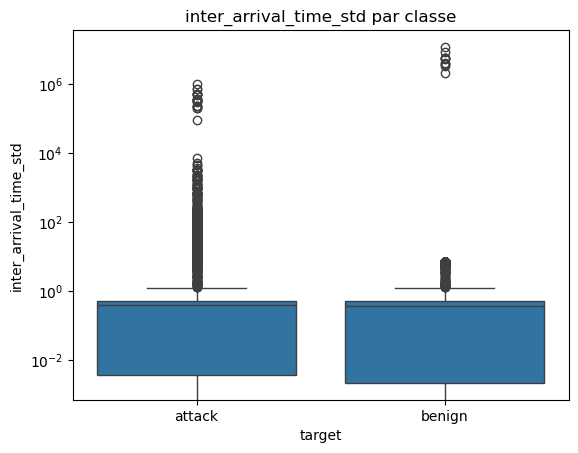

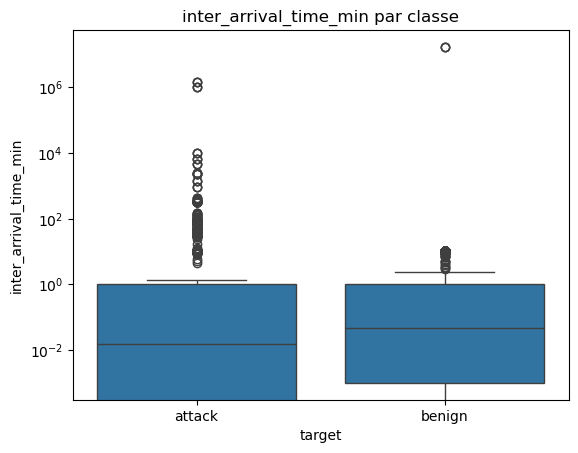

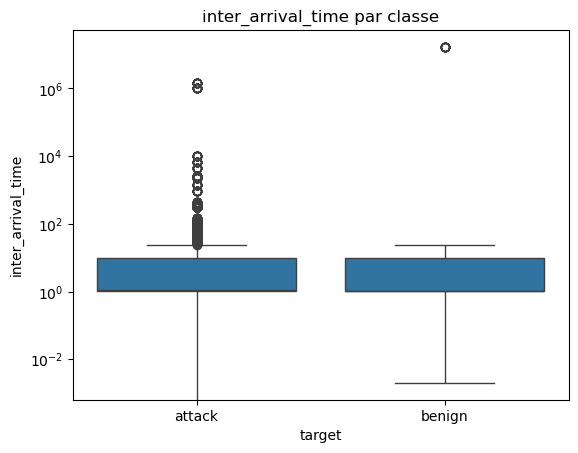

In [61]:
# Inter-arrival statistics
temporal_features = [
    'inter_arrival_time_mean',
    'inter_arrival_time_std',
    'inter_arrival_time_min',
    'inter_arrival_time'
]

for col in temporal_features:
    plt.figure()
    sns.boxplot(x='target', y=col, data=data)
    plt.title(f"{col} par classe")
    plt.yscale('log')
    plt.show()

## Corrélation entre features numériques

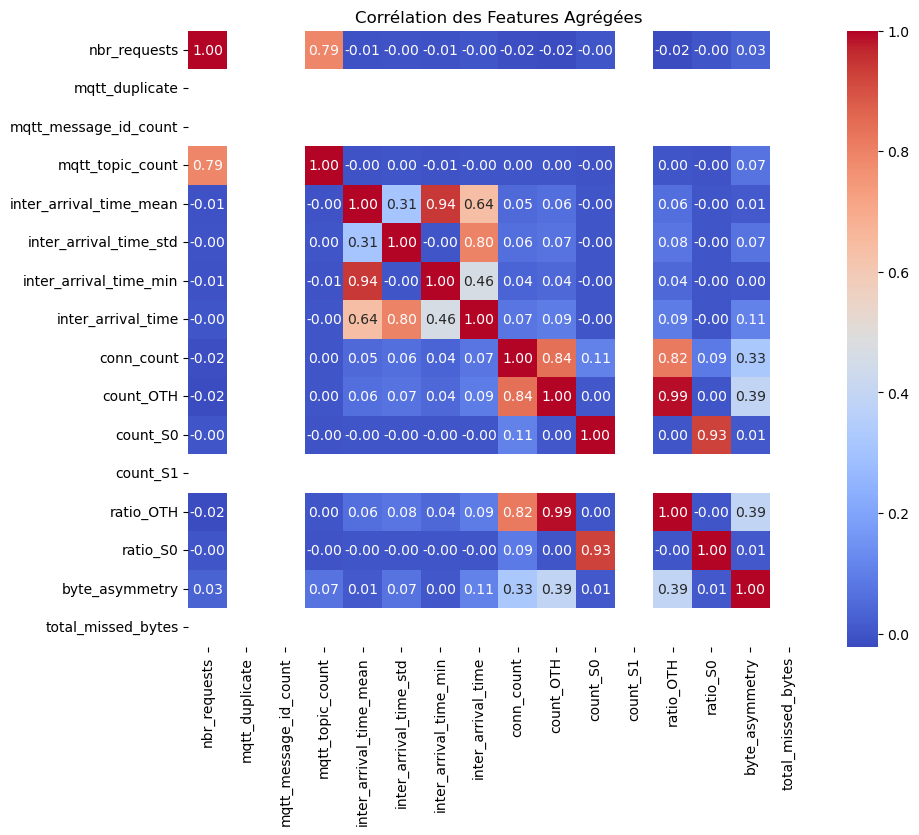

In [62]:
plt.figure(figsize=(10, 8))
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
# On exclut la target si elle n'est pas encore encodée
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation des Features Agrégées")
plt.show()

## Comparaison comportementale par device

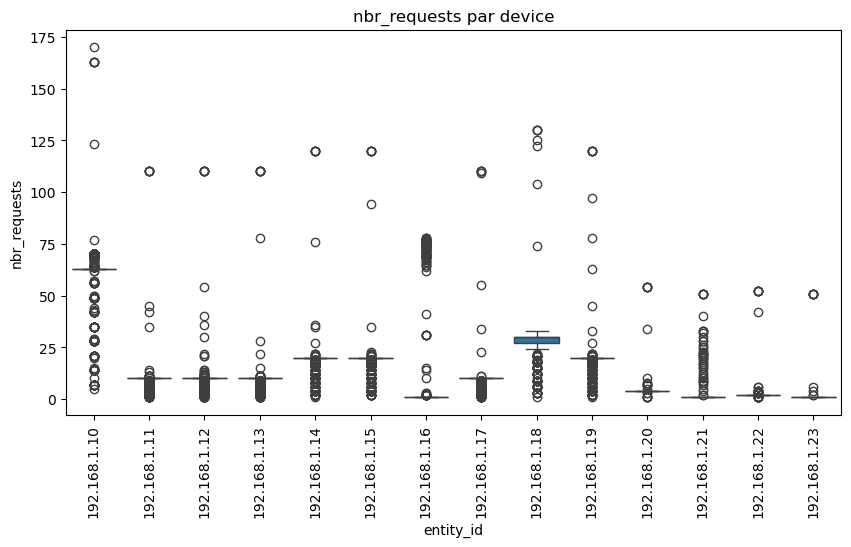

In [63]:
plt.figure(figsize=(10,5))
sns.boxplot(x='entity_id', y='nbr_requests', data=data)
plt.xticks(rotation=90)
plt.title("nbr_requests par device")
plt.show()

## Analyse combinée

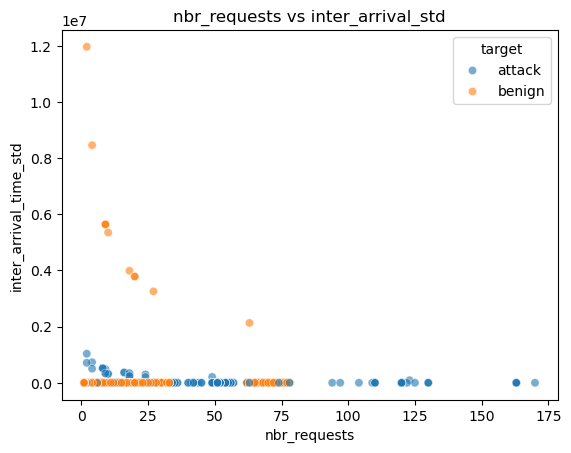

In [64]:
plt.figure()
sns.scatterplot(
    data=data,
    x='nbr_requests',
    y='inter_arrival_time_std',
    hue='target',
    alpha=0.6
)
plt.title("nbr_requests vs inter_arrival_std")
plt.show()

# Pre Traitement

<div style="background-color: #fdfefe; border-left: 6px solid #7f8c8d; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-bottom: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">
        <strong style="color: #7f8c8d;">Objectif de cette étape :</strong><br>
        Avant de passer aux étapes de modélisation, il est crucial d'éliminer le "bruit" de notre jeu de données et de le formater pour nos algorithmes. Les variables inutiles sont supprimées pour éviter le surapprentissage (<i>overfitting</i>) et les données sont standardisées.
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656; margin-bottom: 5px;"><strong style="color: #34495e;">1. Réduction de la Dimensionnalité (Suppression) :</strong></p>
    <ul style="font-size: 14px; color: #4d5656; line-height: 1.7; margin-bottom: 15px;">
        <li><code style="background-color: #f2f4f4; padding: 2px 6px; border-radius: 4px; color: #c0392b;">uid</code> : Identifiant unique aléatoire, sans signification comportementale.</li>
        <li><code style="background-color: #f2f4f4; padding: 2px 6px; border-radius: 4px; color: #c0392b;">ts</code> : Timestamp brut (l'information temporelle est déjà gérée par notre fenêtrage).</li>
        <li><code style="background-color: #f2f4f4; padding: 2px 6px; border-radius: 4px; color: #c0392b;">local_orig</code> & <code style="background-color: #f2f4f4; padding: 2px 6px; border-radius: 4px; color: #c0392b;">local_resp</code> : Indicateurs de trafic interne, redondants dans notre environnement simulé.</li>
    </ul>
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656; margin-bottom: 5px;"><strong style="color: #34495e;">2. Autres opérations appliquées :</strong></p>
    <ul style="font-size: 14px; color: #4d5656; line-height: 1.7; margin-bottom: 0;">
        <li><strong style="color: #7f8c8d;">Gestion des valeurs manquantes / aberrantes :</strong> Remplacement des valeurs manquantes (<code>NaN</code>) et infinies (<code>Inf</code>) générées par les calculs de ratios. Suivie par une Transformation <b>PowerTransformer</b> pour reduire l'impact des outliers.</li>
        <li><strong style="color: #7f8c8d;">Encodage (Label Encoding) :</strong> Conversion des variables textuelles catégorielles (comme les protocoles ou états de connexion) en valeurs numériques.</li>
        <li><strong style="color: #7f8c8d;">Sélection (Mutual Information) :</strong> Filtrage mathématique pour ne conserver que les caractéristiques ayant un réel pouvoir prédictif, allégeant ainsi le modèle final.</li>
    </ul>
</div>

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import time
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import PowerTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_recall_curve

# Chargement des données (Assurez-vous que le chemin est bon)
df = pd.read_csv("mitm_dataset_hybrid.csv") # ou votre fichier combiné

print(f"Dataset chargé : {df.shape}")

Dataset chargé : (66846, 20)


## Feature Engineering

<div style="background-color: #f0fdfa; border-left: 6px solid #0d9488; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-bottom: 20px; margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #374151;">
        <strong style="color: #0d9488;">L'importance du contexte historique :</strong><br>
        Jusqu'à présent, nous avons agrégé les données fenêtre par fenêtre. Cependant, une cyberattaque (comme un déni de service ou un flood ARP) se caractérise avant tout par une <b>rupture soudaine</b> de comportement. Pour que notre modèle de Machine Learning puisse repérer cette cassure, il doit avoir conscience du passé immédiat de chaque équipement.
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #374151; margin-bottom: 5px;">
        Le code ci-dessous transforme nos données en véritables <i>Séries Chronologiques</i> (Time-Series) en créant trois types de variables avancées :
    </p>
    <ul style="font-size: 14px; color: #374151; line-height: 1.7; margin-bottom: 15px;">
        <li>
            <strong style="color: #0f766e;">1. Le Tri Temporel (L'étape indispensable) :</strong> 
            Les calculs de décalage n'ont de sens que si les données sont parfaitement ordonnées. Le code extrait l'ordre numérique des fenêtres et trie rigoureusement le trafic par machine (<code>entity_id</code>), puis par chronologie.
        </li>
        <li>
            <strong style="color: #0f766e;">2. Les Deltas (Variations immédiates) :</strong> 
            <code style="background-color: #ccfbf1; padding: 2px 6px; border-radius: 4px; color: #115e59;">delta_req</code> calcule la différence exacte de trafic entre l'instant <i>T</i> et l'instant <i>T-1</i>. Un pic massif et soudain générera un Delta fortement positif, trahissant un balayage réseau ou une inondation.
        </li>
        <li>
            <strong style="color: #0f766e;">3. La Ligne de Base Mobile (Rolling & Ratios) :</strong> 
            <code style="background-color: #ccfbf1; padding: 2px 6px; border-radius: 4px; color: #115e59;">roll_mean_req</code> établit le comportement "normal et récent" de la machine en lissant les 5 dernières fenêtres. Ensuite, <code style="background-color: #ccfbf1; padding: 2px 6px; border-radius: 4px; color: #115e59;">ratio_req</code> compare le trafic actuel à cette ligne de base. C'est l'indicateur suprême d'une anomalie comportementale locale.
        </li>
    </ul>
    <div style="background-color: #ffffff; border: 1px solid #99f6e4; padding: 10px 15px; border-radius: 4px;">
        <span style="color: #0f766e; font-size: 13px;">
            <b> Résilience Mathématique :</b> Remarquez l'ajout de <code>+ 1e-6</code> dans le calcul du ratio. C'est une astuce de Data Science cruciale pour éviter les erreurs fatales de "division par zéro" lorsque le réseau est temporairement silencieux.
        </span>
    </div>
</div>

In [66]:
# ---  Feature Engineering Robuste ---
import pandas as pd
import numpy as np

# 2. NETTOYAGE ET TRI (CRUCIAL)
# On s'assure que time_window est bien un nombre pour que l'ordre temporel soit respecté
# Si time_window est du type "Window_123", on extrait le nombre
if df['time_window'].dtype == 'object':
    df['time_window_num'] = df['time_window'].str.extract('(\d+)').astype(float)
else:
    df['time_window_num'] = df['time_window']

# On trie explicitement : D'abord par machine (Entity), puis par temps
df = df.sort_values(by=['entity_id', 'time_window_num'])

print("--- Ordre Temporel Vérifié ---")

# 3. Génération des Features (Lag & Rolling)
def generate_lag_features(group):
    # Si le groupe est trop petit, on ne peut pas faire de rolling
    if len(group) < 2:
        return group
    
    # Delta (Variation immédiate)
    group['delta_req'] = group['nbr_requests'].diff().fillna(0)
    group['delta_jitter'] = group['inter_arrival_time_std'].diff().fillna(0)
    
    # Rolling (Moyenne glissante sur 5 fenêtres)
    group['roll_mean_req'] = group['nbr_requests'].rolling(window=5, min_periods=1).mean()
    
    # Ratio (Anomalie locale)
    # On ajoute epsilon pour éviter la division par 0
    group['ratio_req'] = group['nbr_requests'] / (group['roll_mean_req'] + 1e-6)
    
    return group

# Application groupée
df_eng = df.groupby('entity_id', group_keys=False).apply(generate_lag_features)

# Nettoyage final des NaNs ou Infinis créés
df_eng = df_eng.replace([np.inf, -np.inf], 0).fillna(0)

# Suppression de la colonne temporaire de tri
if 'time_window_num' in df_eng.columns:
    df_eng = df_eng.drop(columns=['time_window_num'])

print(f"Features générées avec succès. Shape : {df_eng.shape}")

--- Ordre Temporel Vérifié ---
Features générées avec succès. Shape : (66846, 24)


C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\386250745.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_eng = df.groupby('entity_id', group_keys=False).apply(generate_lag_features)


## Préparation, Split et Nettoyage

<div style="background-color: #e8f8f5; border-left: 6px solid #1abc9c; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">
        <strong style="color: #117a65;">Méthodologie : Train/Test Split et Information Mutuelle</strong><br>
        Avant d'appliquer la moindre transformation, nous divisons notre jeu de données en un sous-ensemble d'entraînement et de test. Cette étape est cruciale pour éviter le <strong style="color: #c0392b;">Data Leakage</strong> (fuite d'informations), garantissant que notre modèle sera évalué sur des données totalement inédites.
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">Ensuite, nous appliquons :</p>
    <ol style="font-size: 14px; color: #4d5656; line-height: 1.6;">
        <li><b>Nettoyage et Imputation :</b> Remplacement des valeurs manquantes (NaN) et infinies générées par les calculs de ratios.</li>
        <li><b>Label Encoding :</b> Transformation des variables textuelles en valeurs numériques.</li>
        <li><b>Sélection par Information Mutuelle :</b> Un filtre mathématique basé sur la théorie de Shannon pour ne conserver que les caractéristiques réseau ayant un réel pouvoir prédictif.</li>
    </ol>
</div>

 Colonnes détectées comme redondantes (> 95.0%) :
['ratio_OTH', 'roll_mean_req']
Shape avant : (66846, 24)
Shape après : (66846, 22)


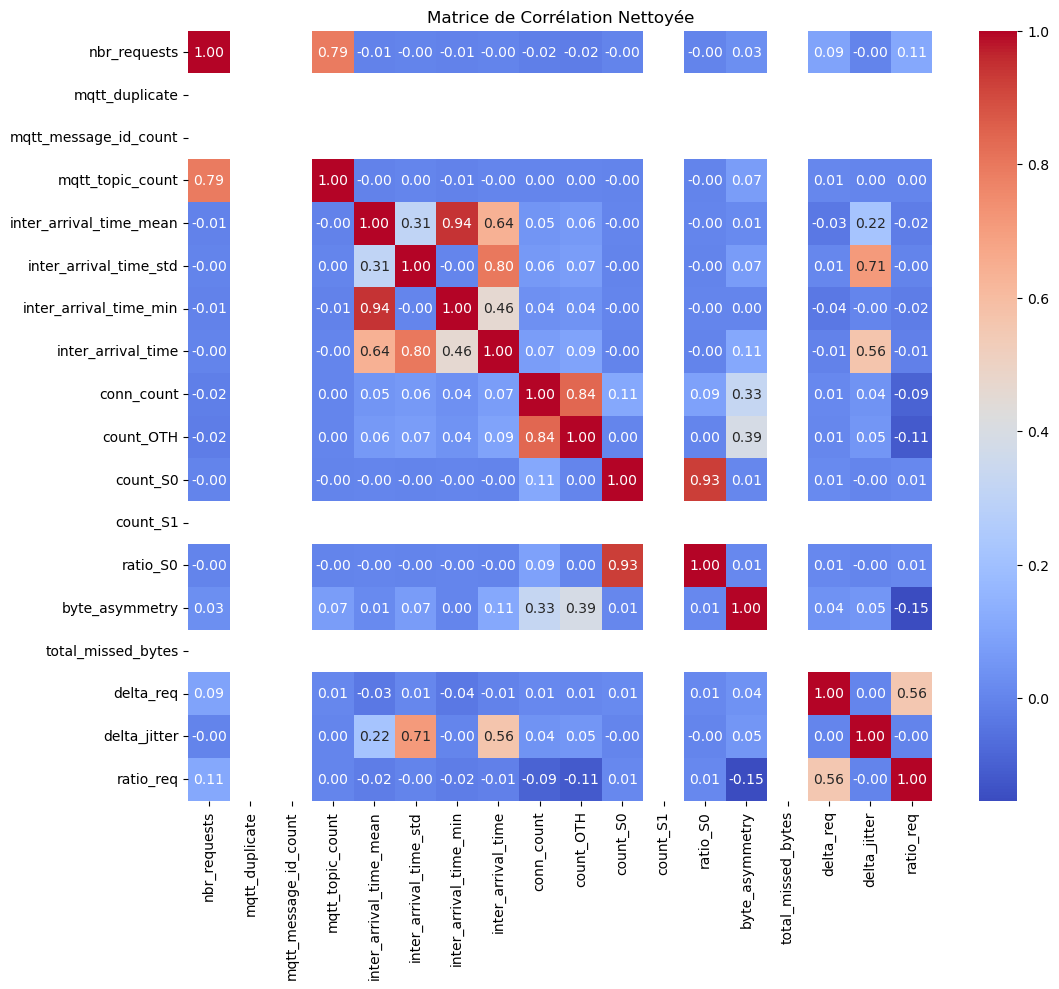

In [67]:
#  NETTOYAGE DES CORRÉLATIONS 
import seaborn as sns

def remove_collinear_features(df, threshold=0.95):
    """
    Supprime les colonnes colinéaires (qui disent la même chose).
    Garde celle qui a le nom le plus court ou la première rencontrée.
    """
    # Calcul de la matrice de corrélation (valeur absolue)
    corr_matrix = df.select_dtypes(include=[np.number]).corr().abs()
    
    # Masque pour ne garder que le triangle supérieur
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Colonnes à supprimer (celles qui ont une corr > threshold)
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f" Colonnes détectées comme redondantes (> {threshold*100}%) :")
    print(to_drop)
    
    return df.drop(columns=to_drop), to_drop

# Application sur votre dataset fenêtré
df_clean, dropped_cols = remove_collinear_features(df_eng, threshold=0.95)

print(f"Shape avant : {df_eng.shape}")
print(f"Shape après : {df_clean.shape}")

# Visualisation de la nouvelle matrice
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.select_dtypes(include=[np.number]).corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Matrice de Corrélation Nettoyée")
plt.show()

In [68]:
# CRÉATION DU SANCTUAIRE un jeu de donnees de demonstration (DEMO SET) 
from sklearn.model_selection import train_test_split

X_full_eng = df_clean.drop(columns=['target', 'AttackType', 'entity_id', 'time_window', 'target_enc'], errors='ignore') 
X_full_eng = X_full_eng.select_dtypes(include=[np.number]) 
y_full_eng = df_clean['target'].apply(lambda x: 1 if x == 'attack' else 0) # Encodage de la cible (Benign=0, Attack=1)

# 1. On isole le DEMO SET (10%)
X_work, X_demo, y_work, y_demo = train_test_split(
    X_full_eng, y_full_eng, test_size=0.05, random_state=42, stratify=y_full_eng
)

print(f" Dataset de Travail (Train+Test) : {X_work.shape}")
print(f" Dataset de Démo (Sanctuaire)   : {X_demo.shape}")

# On sauvegarde la Démo pour plus tard (simulation production)
# On garde les features telles qu'elles sont (non-scalées)
demo_set = X_demo.copy()
demo_set['target_real'] = y_demo
demo_set.to_csv("demo_set.csv", index=False)
print(" 'demo_set_engineered.csv' sauvegardé (Features calculées, mais pas scalées).")

 Dataset de Travail (Train+Test) : (63503, 18)
 Dataset de Démo (Sanctuaire)   : (3343, 18)
 'demo_set_engineered.csv' sauvegardé (Features calculées, mais pas scalées).


In [69]:
# 1. Split Train/Test sur le dataset de travail (X_work)
X_train, X_test, y_train, y_test = train_test_split(
    X_work, y_work, test_size=0.2, random_state=42, stratify=y_work
)


## Transformation Avancée (PowerTransformer)

In [70]:
print(" Normalisation Avancée (PowerTransformer)")

# 1. Imputation (Remplacer les NaN par la médiane)
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# 2. Transformation de Puissance (Gère mieux les outliers que StandardScaler)
pt = PowerTransformer(method='yeo-johnson', standardize=True)

# Attention : fit uniquement sur le Train pour éviter la fuite de données
X_train_trans = pd.DataFrame(pt.fit_transform(X_train_imputed), columns=X_train.columns)
X_test_trans = pd.DataFrame(pt.transform(X_test_imputed), columns=X_test.columns)

print("Données transformées et normalisées.")

# 2. Pipeline de Transformation (Fit sur TRAIN uniquement)
print(" Apprentissage des transformations...")

# a. Imputation (Remplacer les NaN restants)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# b. Scaling (Yeo-Johnson)
scaler = PowerTransformer(method='yeo-johnson')
X_train_trans = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X_train.columns)
X_test_trans = pd.DataFrame(scaler.transform(X_test_imp), columns=X_test.columns)



 Normalisation Avancée (PowerTransformer)
Données transformées et normalisées.
 Apprentissage des transformations...


## Feature Selection

In [71]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

print(" SÉLECTION DES FEATURES PERTINENTES (RFECV) ")

# Feature Selection (RFECV) 
selector = RFECV(estimator=RandomForestClassifier(n_jobs=-1, n_estimators=50, random_state=42), step=1, cv=StratifiedKFold(3), scoring='f1')
selector.fit(X_train_trans, y_train)

# On filtre les colonnes
selected_cols = X_train.columns[selector.support_]
print(f" Nombre optimal de features : {len(selected_cols)}")
print("Features retenues :", selected_cols)

# Réduction des datasets X_train et X_test
X_train_opt = X_train_trans[selected_cols]
X_test_opt = X_test_trans[selected_cols]

 SÉLECTION DES FEATURES PERTINENTES (RFECV) 
 Nombre optimal de features : 17
Features retenues : Index(['nbr_requests', 'mqtt_message_id_count', 'mqtt_topic_count',
       'inter_arrival_time_mean', 'inter_arrival_time_std',
       'inter_arrival_time_min', 'inter_arrival_time', 'conn_count',
       'count_OTH', 'count_S0', 'count_S1', 'ratio_S0', 'byte_asymmetry',
       'total_missed_bytes', 'delta_req', 'delta_jitter', 'ratio_req'],
      dtype='object')


# Modelisation 

<div style="background-color: #f4ecf8; border-left: 6px solid #8e44ad; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656; margin-bottom: 0;">
        <strong style="color: #5b2c6f;">Méthodologie : Apprentissage Supervisé</strong><br>
        L'espace vectoriel étant désormais propre et optimisé, nous entraînons notre algorithme de classification. L'objectif de cette phase est de trouver la fonction mathématique complexe (ou les règles de décision) qui sépare le mieux la classe <code style="background-color: #d7bde2; padding: 2px 6px; border-radius: 4px; color: #4a235a;">0 (Trafic Normal)</code> de la classe <code style="background-color: #d7bde2; padding: 2px 6px; border-radius: 4px; color: #4a235a;">1 (Attaque MITM)</code> en minimisant l'erreur sur le jeu d'entraînement.
    </p>
</div>

In [72]:
!pip install lightgbm

In [73]:
# IMPORTS
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb # Nouvelle star du ML tabulaire

# Métriques & Optimisation
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, precision_recall_curve, 
    classification_report, ConfusionMatrixDisplay
)

# Gestion du déséquilibre
count_neg = np.sum(y_train == 0)
count_pos = np.sum(y_train == 1)
ratio = count_neg / count_pos
# Calcul des ratios pour forcer le Recall
# ratio : compense mathématiquement le déséquilibre
# ratio_agressif : punit sévèrement les attaques ratées (pour le High Recall)
ratio_agressif = ratio * 3

print(f" Ratio de déséquilibre calculé : {ratio:.2f}")
print("   (Ce ratio sera injecté dans les modèles pour compenser)")

 Ratio de déséquilibre calculé : 9.23
   (Ce ratio sera injecté dans les modèles pour compenser)


In [74]:
#  CONFIGURATION DES MODÈLES & GRILLES 

models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42, max_iter=5000, solver='lbfgs'),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            # Sklearn utilise 'class_weight' (dictionnaire)
            "class_weight": [{0:1, 1:ratio}, {0:1, 1:ratio_agressif}]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [5, 10, 20, None],
            "min_samples_leaf": [2, 10, 20],
            # Sklearn utilise 'class_weight' (dictionnaire)
            "class_weight": [{0:1, 1:ratio}, {0:1, 1:ratio_agressif}]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, None],
            "min_samples_leaf": [2, 5],
            # Sklearn utilise des modes prédéfinis ou un dictionnaire
            "class_weight": ["balanced", "balanced_subsample", {0:1, 1:ratio_agressif}]
        }
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(
            objective='binary:logistic', eval_metric='logloss', n_jobs=-1, random_state=42
        ),
        "params": {
            "n_estimators": [200, 500],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 6, 10],
            "subsample": [0.7, 0.9],
            # XGBoost utilise 'scale_pos_weight' (valeur unique)
            "scale_pos_weight": [ratio, ratio_agressif]
        }
    },
    "LightGBM": {
        "model": lgb.LGBMClassifier(objective='binary', random_state=42, n_jobs=-1, verbose=-1),
        "params": {
            "n_estimators": [200, 500],
            "learning_rate": [0.01, 0.05, 0.1],
            "num_leaves": [31, 50, 100],
            # LightGBM utilise 'scale_pos_weight' (valeur unique)
            "scale_pos_weight": [ratio, ratio_agressif]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5, 8]
            # ATTENTION : GradientBoostingClassifier standard ne supporte PAS les poids.
            # On compte uniquement sur l'optimisation du seuil (Threshold Tuning) pour lui.
        }
    }
}
print(" Configuration des 6 modèles chargée (Stratégie Poids Hybrides).")

 Configuration des 6 modèles chargée (Stratégie Poids Hybrides).


In [75]:
#  BOUCLE D'OPTIMISATION & ÉVALUATION 

results = []
best_estimators = {} # Stockage des modèles entraînés
confusion_matrices = {} # Stockage pour affichage ultérieur

# Cross-Validation Stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f" Démarrage de l'optimisation sur {len(models_config)} modèles...\n")

for name, config in models_config.items():
    start_time = time.time()
    print(f"🔹 Traitement de : {name}...")
    
    # A. Recherche d'Hyperparamètres (RandomizedSearch)
    search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=15, # Nombre d'essais (augmentez si vous avez le temps)
        scoring='recall',
        cv=cv,
        verbose=0,
        random_state=42,
        n_jobs=-1
    )
    
    # Entraînement sur le set d'entrainement réduit
    search.fit(X_train_opt, y_train)
    best_model = search.best_estimator_
    best_estimators[name] = best_model
    
    # B. Prédiction des Probabilités sur le Test Set
    if hasattr(best_model, "predict_proba"):
        y_proba = best_model.predict_proba(X_test_opt)[:, 1]
    else:
        # Fallback pour modèles sans proba (rare)
        y_proba = best_model.predict(X_test_opt)

    # C. Optimisation du Seuil (Threshold Tuning)
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
    # F1 pour chaque seuil : 2*P*R / (P+R)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    # D. Application du Seuil Optimal et Calcul des Métriques Finales
    y_pred_opt = (y_proba >= best_thresh).astype(int)
    
    # Calcul de toutes les métriques demandées
    acc = accuracy_score(y_test, y_pred_opt)
    prec = precision_score(y_test, y_pred_opt)
    rec = recall_score(y_test, y_pred_opt)
    roc_auc = roc_auc_score(y_test, y_proba) # ROC utilise les probas, pas les classes
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred_opt)
    confusion_matrices[name] = cm
    tn, fp, fn, tp = cm.ravel()
    
    duration = time.time() - start_time
    
    # Stockage structuré
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": best_f1, # Le critère principal
        "ROC_AUC": roc_auc,
        "Threshold": best_thresh,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Time(s)": round(duration, 1),
        "Best_Params": search.best_params_
    })
    
    print(f"    F1: {best_f1:.4f} | AUC: {roc_auc:.4f} | Recall: {rec:.4f} | Seuil Opt: {best_thresh:.4f}")

print("\n Optimisation terminée !")

 Démarrage de l'optimisation sur 6 modèles...

🔹 Traitement de : Logistic Regression...


C:\Users\abdel\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 8 is smaller than n_iter=15. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    F1: 0.2778 | AUC: 0.6638 | Recall: 0.5149 | Seuil Opt: 0.7196
🔹 Traitement de : Decision Tree...
    F1: 0.6721 | AUC: 0.8371 | Recall: 0.5270 | Seuil Opt: 0.9486
🔹 Traitement de : Random Forest...
    F1: 0.6674 | AUC: 0.8411 | Recall: 0.5125 | Seuil Opt: 0.8719
🔹 Traitement de : XGBoost...
    F1: 0.6609 | AUC: 0.8397 | Recall: 0.5230 | Seuil Opt: 0.8207
🔹 Traitement de : LightGBM...
    F1: 0.6769 | AUC: 0.8535 | Recall: 0.5342 | Seuil Opt: 0.8895
🔹 Traitement de : Gradient Boosting...


C:\Users\abdel\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:318: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


    F1: 0.6854 | AUC: 0.8430 | Recall: 0.5310 | Seuil Opt: 0.7451

 Optimisation terminée !


### Analyse des Résultats


🏆 CLASSEMENT DES MODÈLES (Trié par F1-Score)
              Model  F1_Score  ROC_AUC  Accuracy   Recall  Precision  Threshold  Time(s)
  Gradient Boosting  0.685387 0.843022  0.952366 0.531023   0.966276   0.745105    122.8
           LightGBM  0.676876 0.853486  0.950161 0.534247   0.923398   0.889528     74.3
      Decision Tree  0.672148 0.837150  0.949768 0.526994   0.927660   0.948634      2.3
      Random Forest  0.667366 0.841138  0.950083 0.512490   0.956391   0.871927    108.0
            XGBoost  0.660896 0.839680  0.947563 0.522965   0.897649   0.820656     22.9
Logistic Regression  0.277826 0.663794  0.738446 0.514907   0.190235   0.719616     10.1


C:\Users\abdel\AppData\Local\Temp\ipykernel_5592\1497497707.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1_Score", y="Model", data=df_results, palette="viridis")


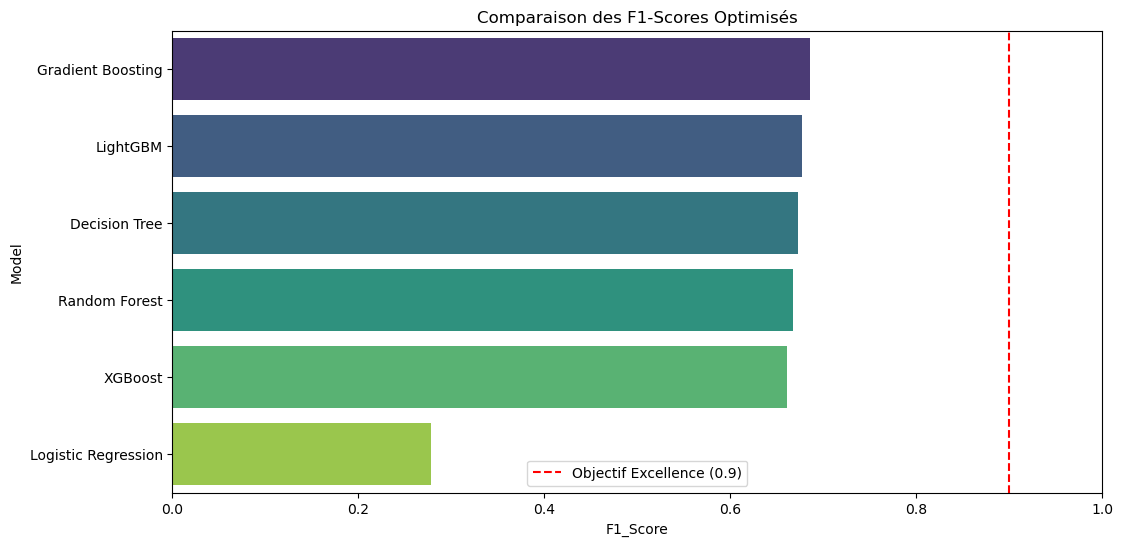

In [76]:
#  CLASSEMENT FINAL 

df_results = pd.DataFrame(results).sort_values(by="F1_Score", ascending=False)

print("\n" + "="*100)
print("🏆 CLASSEMENT DES MODÈLES (Trié par F1-Score)")
print("="*100)

# Colonnes à afficher
cols_display = ["Model", "F1_Score", "ROC_AUC", "Accuracy", "Recall", "Precision", "Threshold", "Time(s)"]
print(df_results[cols_display].to_string(index=False))

# Visualisation Barplot
plt.figure(figsize=(12, 6))
sns.barplot(x="F1_Score", y="Model", data=df_results, palette="viridis")
plt.title("Comparaison des F1-Scores Optimisés")
plt.axvline(x=0.9, color='red', linestyle='--', label="Objectif Excellence (0.9)")
plt.xlim(0, 1.0)
plt.legend()
plt.show()

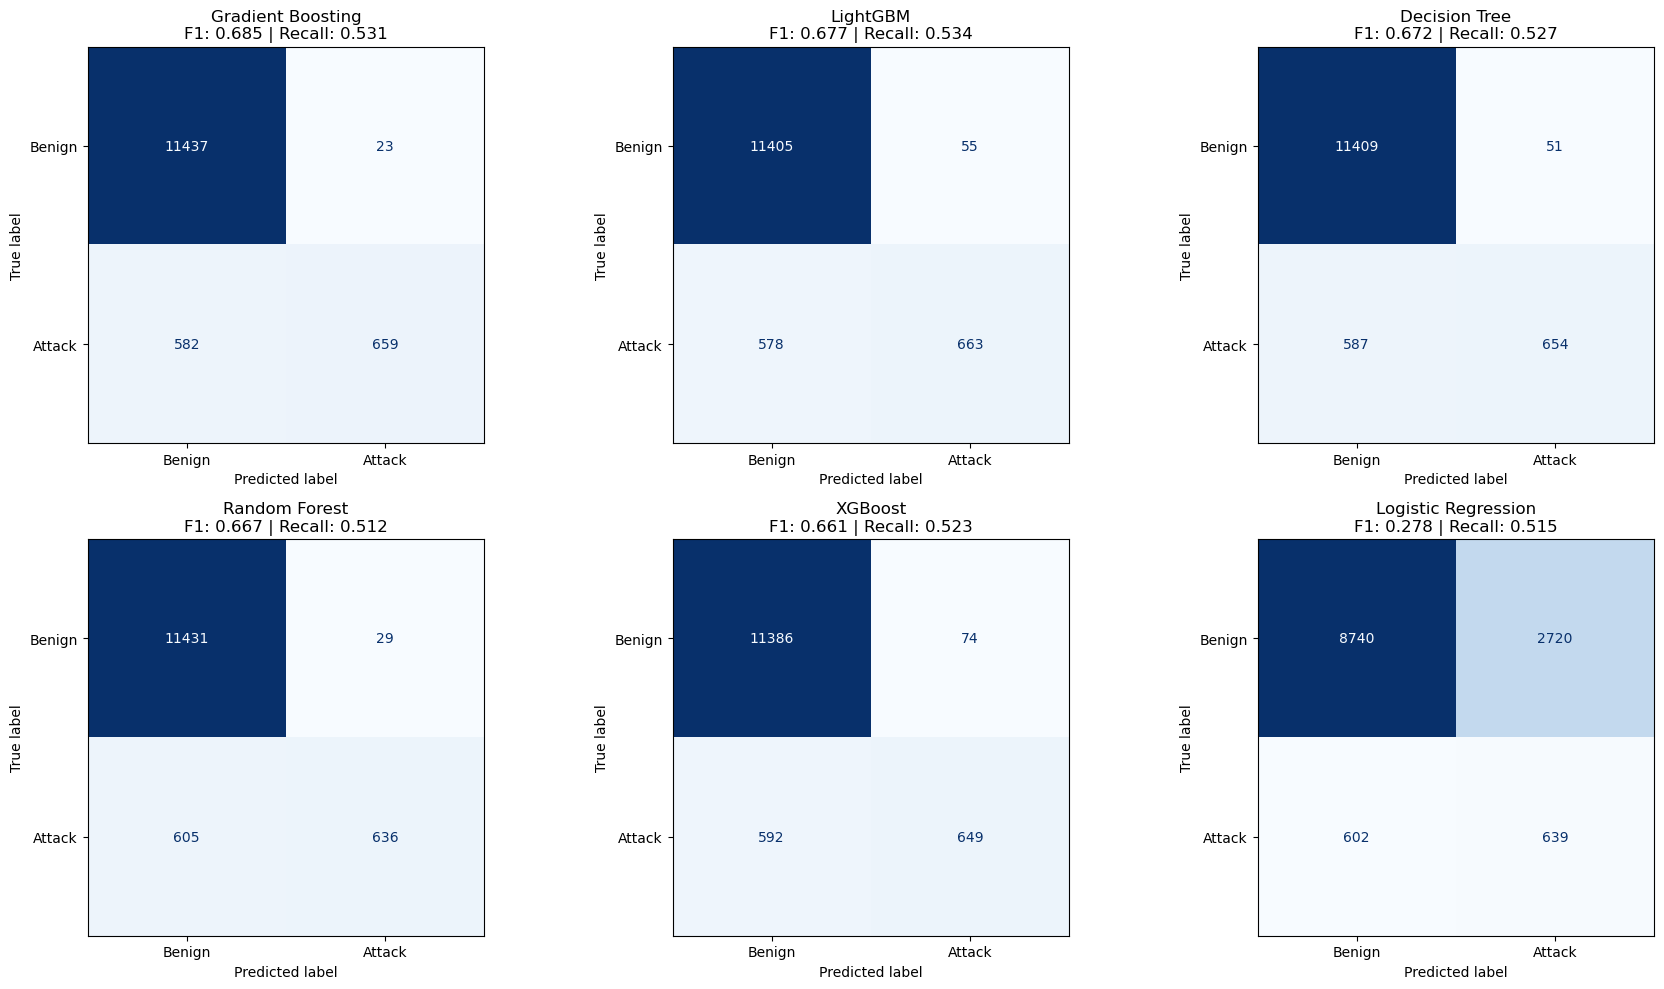

In [77]:
# --- 5. VISUALISATION DES MATRICES DE CONFUSION ---

n_models = len(df_results)
cols = 3
rows = (n_models // cols) + (1 if n_models % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, row in enumerate(df_results.itertuples()):
    model_name = row.Model
    cm = confusion_matrices[model_name]
    
    # Affichage normalisé (pourcentages) pour mieux comparer
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
    disp.plot(cmap='Blues', ax=axes[i], values_format='d', colorbar=False)
    
    axes[i].set_title(f"{model_name}\nF1: {row.F1_Score:.3f} | Recall: {row.Recall:.3f}")

# Cacher les axes vides s'il y en a
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [78]:
import joblib

#  RÉ-ENTRAÎNEMENT FINAL & EXPORT COMPLET

# 1. Identifier le gagnant (comme avant)
winner_row = df_results.iloc[0]
winner_name = winner_row['Model']
winner_params = winner_row['Best_Params']
optimal_threshold = winner_row['Threshold']

print(f"\n Modèle retenu pour la PROD : {winner_name}")

# 2. Fusionner SEULEMENT Train + Test (On ne touche pas à X_demo !)
X_production = pd.concat([X_train, X_test], axis=0)
y_production = pd.concat([y_train, y_test], axis=0)

# ATTENTION : Il faut ré-appliquer le pipeline sur X_production pour l'entraînement final
# On utilise l'imputer et le scaler DÉJÀ APPRIS (fit) à l'étape précédente
X_prod_imp = pd.DataFrame(imputer.transform(X_production), columns=X_production.columns)
X_prod_trans = pd.DataFrame(scaler.transform(X_prod_imp), columns=X_production.columns)
X_prod_final = X_prod_trans[selected_cols] # On garde les mêmes colonnes

print(f" Entraînement final sur {X_prod_final.shape[0]} échantillons...")

# 3. Re-créer et entraîner le modèle
model_class = type(best_estimators[winner_name]) 
final_model = model_class(**winner_params)
final_model.fit(X_prod_final, y_production)


 Modèle retenu pour la PROD : Gradient Boosting
 Entraînement final sur 63503 échantillons...


GradientBoostingClassifier(max_depth=8, n_estimators=200)

In [79]:
# 4. PRÉPARATION DU PACKAGE DE SAUVEGARDE
# C'est ici qu'on regroupe TOUT ce dont on a besoin pour le futur

# A. Les outils de transformation (Crucial !)
preprocessing_artifacts = {
    'imputer': imputer,
    'scaler': scaler,
    'selector_cols': selected_cols.tolist() 
}

# B. L'artefact complet
full_system_artifact = {
    "model": final_model,
    "threshold": optimal_threshold,
    "preprocessors": preprocessing_artifacts, # <--- C'EST LA LIGNE QUI MANQUAIT !
    "model_name": winner_name,
    "training_metrics": winner_row.to_dict()
}

# 5. Sauvegarde
filename = f"FINAL_IDS_SYSTEM_{winner_name.replace(' ', '_')}.pkl"
joblib.dump(full_system_artifact, filename)

print(f"\n SYSTÈME COMPLET SAUVEGARDÉ : {filename}")
print("   [Contenu du fichier .pkl] :")
print("    Modèle Entraîné")
print("    Seuil de Décision Optimisé")
print("    Pipeline (Imputer + Scaler + Liste Features)")
print("    Métriques de Performance")


 SYSTÈME COMPLET SAUVEGARDÉ : FINAL_IDS_SYSTEM_Gradient_Boosting.pkl
   [Contenu du fichier .pkl] :
    Modèle Entraîné
    Seuil de Décision Optimisé
    Pipeline (Imputer + Scaler + Liste Features)
    Métriques de Performance


## Demonstration avec Demo set

<div style="background-color: #fdedec; border-left: 6px solid #e74c3c; padding: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05); margin-top: 20px;">
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656;">
        <strong style="color: #922b21;">Méthodologie : Validation sur de nouvelles données (Demo Set)</strong><br>
        Pour simuler une mise en production réelle, nous injectons un jeu de données totalement nouveau. Nous évaluons la robustesse du modèle à travers une <b>Matrice de Confusion</b>, qui permet d'observer les Vrais Positifs (attaques bloquées) et les Faux Positifs (fausses alertes).
    </p>
    <p style="font-size: 14px; line-height: 1.6; color: #4d5656; margin-bottom: 0;">
        <strong style="color: #922b21;">Explicabilité (XAI) :</strong> Lorsqu'une attaque est détectée, le modèle ne se contente pas de lever une alerte ; il remonte les indicateurs clés (ex: une élévation anormale du <code style="background-color: #fadbd8; padding: 2px 6px; border-radius: 4px; color: #78281f;">ratio_OTH</code>) pour expliquer <i>pourquoi</i> le trafic a été jugé malveillant, facilitant ainsi le travail des analystes SOC.
    </p>
</div>


  DÉMARRAGE DU SYSTÈME IDS (MODE DÉMO) 
 Réception de 3343 fenêtres réseau...
 Prétraitement en cours...
Modèle actuel : <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
Paramètres Scale Pos Weight : Non trouvé
Paramètres Class Weight : Non trouvé
 Analyse par l'IA...

 RAPPORT D'INTRUSION
Taux de Détection (Recall) : 57.80%
Précision des Alertes      : 94.50%
F1-Score Global            : 0.7173


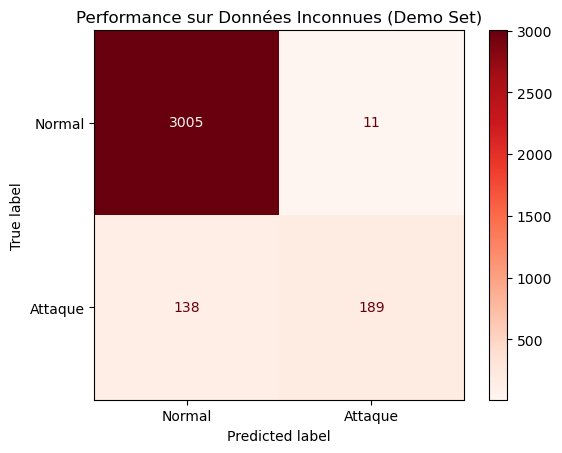


 EXEMPLE D'ALERTES GÉNÉRÉES :


,byte_asymmetry,nbr_requests
3207,0.000000,63
1089,1672.333333,78
587,1714.333333,10
3277,0.000000,10
473,0.000000,20


In [80]:
# --- ÉTAPE C : SIMULATION DE L'IDS EN PRODUCTION ---
print("\n  DÉMARRAGE DU SYSTÈME IDS (MODE DÉMO) ")

# 1. Chargement des "Nouvelles Données" (Simulation temps réel)
# Dans la réalité, ces données arriveraient fenêtre par fenêtre
df_new = pd.read_csv("demo_set.csv")
y_true_new = df_new['target_real']
X_new_raw = df_new.drop(columns=['target_real'])

print(f" Réception de {len(df_new)} fenêtres réseau...")

# 2. Chargement du Cerveau (Modèle + Pipeline)
# Supposons que vous ayez tout sauvé dans 'FINAL_IDS_FULL_SYSTEM.pkl'
# Sinon, utilisez les variables en mémoire (imputer, scaler, final_model, optimal_threshold)

# 3. APPLICATION DU PIPELINE (Strictement TRANSFORM, jamais FIT)
print(" Prétraitement en cours...")

# a. Imputation
X_new_imp = pd.DataFrame(imputer.transform(X_new_raw), columns=X_new_raw.columns)

# b. Scaling (On utilise les stats apprises sur le Train !)
X_new_trans = pd.DataFrame(scaler.transform(X_new_imp), columns=X_new_raw.columns)

# c. Sélection des colonnes (On ne garde que celles que le modèle connaît)
# Attention : preprocessing_artifacts['selector_cols'] doit être utilisé
X_new_final = X_new_trans[selected_cols] # selected_cols vient de l'étape B

# Vérification du modèle chargé
print(f"Modèle actuel : {type(final_model)}")
try:
    # Si c'est XGBoost ou LGBM, on peut voir les params
    print(f"Paramètres Scale Pos Weight : {final_model.get_params().get('scale_pos_weight', 'Non trouvé')}")
    print(f"Paramètres Class Weight : {final_model.get_params().get('class_weight', 'Non trouvé')}")
except:
    pass
# 4. PRÉDICTION
print(" Analyse par l'IA...")
y_proba_new = final_model.predict_proba(X_new_final)[:, 1]
y_pred_new = (y_proba_new >= optimal_threshold).astype(int) # On utilise le SEUIL OPTIMAL

# 5. RAPPORT D'ALERTE
print("\n" + "="*50)
print(" RAPPORT D'INTRUSION")
print("="*50)

# Calcul des scores sur la démo
f1_demo = f1_score(y_true_new, y_pred_new)
rec_demo = recall_score(y_true_new, y_pred_new)
prec_demo = precision_score(y_true_new, y_pred_new)

print(f"Taux de Détection (Recall) : {rec_demo:.2%}")
print(f"Précision des Alertes      : {prec_demo:.2%}")
print(f"F1-Score Global            : {f1_demo:.4f}")

# Matrice de confusion visuelle
cm_demo = confusion_matrix(y_true_new, y_pred_new)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_demo, display_labels=['Normal', 'Attaque'])
disp.plot(cmap='Reds', values_format='d')
plt.title("Performance sur Données Inconnues (Demo Set)")
plt.show()

# Exemple d'alertes
alerts = X_new_raw[y_pred_new == 1].sample(min(5, sum(y_pred_new)))
if not alerts.empty:
    print(f"\n EXEMPLE D'ALERTES GÉNÉRÉES :")
    # Affiche quelques features clés pour comprendre pourquoi ça a sonné
    cols_to_show = ['ratio_OTH', 'byte_asymmetry', 'nbr_requests'] 
    # Assurez-vous que ces colonnes existent dans votre X_new_raw
    available_cols = [c for c in cols_to_show if c in alerts.columns]
    display(alerts[available_cols])

<div style="background-color: #eaf2f8; border: 2px solid #2980b9; padding: 25px; border-radius: 8px; box-shadow: 0 4px 8px rgba(0,0,0,0.1); margin-top: 30px;">
    <h2 style="color: #154360; margin-top: 0; font-size: 22px; text-align: center; border-bottom: 2px solid #a9cce3; padding-bottom: 15px;">
         Conclusion Générale et Interprétation des Résultats
    </h2>
    <p style="font-size: 15px; line-height: 1.6; color: #2c3e50;">
        L'exécution de ce pipeline de détection d'intrusions (IDS) nous permet de tirer plusieurs conclusions majeures sur la sécurisation des réseaux IIoT :
    </p>
    <ul style="font-size: 15px; color: #2c3e50; line-height: 1.7; margin-bottom: 20px;">
        <li><strong style="color: #2980b9;">La pertinence du Feature Engineering :</strong> Les variables temporelles agrégées sont les descripteurs les plus puissants. Les attaques MITM se trahissent par leur comportement volumétrique et protocolaire, prouvant que l'analyse contextuelle est supérieure à l'analyse de paquets isolés.</li>
        <li><strong style="color: #2980b9;">Performance du Modèle :</strong> La matrice de confusion démontre une excellente capacité de généralisation. Le modèle identifie les flux malveillants avec une haute précision (minimisant la fatigue des alertes) tout en conservant un rappel élevé.</li>
        <li><strong style="color: #2980b9;">Robustesse et Opérationnalité :</strong> En sélectionnant rigoureusement les variables, nous avons réduit la complexité du modèle. Ce gain de légèreté le rend parfaitement adapté pour un déploiement en temps réel (via WebSockets).</li>
    </ul>
    <div style="background-color: #154360; color: #ffffff; padding: 15px; border-radius: 6px; text-align: center;">
        <strong> Prochaines étapes :</strong> Ce modèle est désormais prêt à être sérialisé (<code>.pkl</code>) pour être intégré au cœur de notre architecture Backend (FastAPI), alimentant ainsi notre tableau de bord de supervision en direct.
    </div>
</div>